Author: Jessica Xu

This code conducts Exploratory Data Analysis (EDA) on the merged Google Places and Yelp datasets, performs descriptive spatial analysis and mapping with additional visualizations, and runs an OLS linear regression to examine factors associated with restaurant price levels in Chicago.

Documentation:

https://shapely.readthedocs.io/en/2.1.1/reference/shapely.from_wkt.html

https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html

https://matplotlib.org/stable/api/patheffects_api.html

AI used only for debugging and minor modifications.

### Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
import re
import matplotlib.patheffects as pe
import statsmodels.api as sm

In [2]:
# load dataset
BASE_DIR = os.getcwd()

FILENAME = "gp_yelp_matched_cleaned.csv"
FILEPATH = os.path.join(BASE_DIR, FILENAME)
gp_yelp = pd.read_csv(FILEPATH)

# load community area boundaries
BOUNDARY_PATH = "Boundaries_-_Community_Areas_20260202.csv"
BOUNDARY_FILEPATH = os.path.join(BASE_DIR, BOUNDARY_PATH)
bound = pd.read_csv(BOUNDARY_FILEPATH)

# load ACS community area SES
ACS_PATH = "ACS_5_Year_Data_by_Community_Area_20260202.csv"
ACS_FILEPATH = os.path.join(BASE_DIR, ACS_PATH)
acs = pd.read_csv(ACS_FILEPATH)

print("gp_yelp_matched_cleaned rows:", len(gp_yelp))

gp_yelp_matched_cleaned rows: 1968


### EDA

In [3]:
gp_yelp.shape, gp_yelp.columns

((1968, 72),
 Index(['gp_place_id', 'yelp_business_id', 'score', 'dist_m', 'name_sim',
        'addr_sim', 'gp_name', 'gp_address', 'gp_latitude', 'gp_longitude',
        'gp_price_range_raw', 'gp_price_level', 'gp_rating', 'gp_review_count',
        'gp_types', 'gp_primary_type', 'gp_business_status',
        'gp_regular_opening_hours_raw', 'gp_takeout', 'gp_delivery',
        'gp_dine_in', 'gp_reservable', 'gp_query_lat', 'gp_query_lon',
        'gp_specific_address', 'gp_city', 'gp_zipcode', 'gp_country',
        'gp_name_norm', 'gp_price_level_1to4', 'gp_price_start', 'gp_price_end',
        'gp_open_days_per_week', 'gp_total_open_minutes_week',
        'gp_avg_open_minutes_open_day', 'gp_weekend_open_minutes',
        'gp_open_late_minutes', 'gp_takeout_d', 'gp_delivery_d', 'gp_dine_in_d',
        'gp_reservable_d', 'yelp_name', 'yelp_display_address', 'yelp_address1',
        'yelp_zip_code', 'yelp_city', 'yelp_state', 'yelp_latitude',
        'yelp_longitude', 'yelp_price', 'yel

In [4]:
gp_yelp.head()

,gp_place_id,yelp_business_id,score,dist_m,name_sim,addr_sim,gp_name,gp_address,gp_latitude,gp_longitude,...,res_takeout,res_delivery,res_dine_in,res_reservable,res_pickup,res_price_level,has_yelp_type,has_gp_type,res_is_fast_food,res_primary_type
0,ChIJXWbrjRbOD4gRg-xfIH0Zdps,10kJ1164F43wxfxsqleDWA,100.0,0.0,100.0,100.0,Panera Bread,"6059 N Lincoln Ave, Chicago, IL 60659, USA",41.993097,-87.711334,...,1,1,1,0,1,2.0,True,True,0,Sandwiches
1,ChIJpfNniSEvDogRj6kQeD59EO8,lSsA6m35JIvZqhqyl6uTrg,100.0,0.0,100.0,100.0,No Sauce AZ Smokehouse,"133 E 75th St, Chicago, IL 60619, USA",41.757988,-87.620238,...,1,1,1,0,1,2.0,True,True,0,Barbeque
2,ChIJn_Kuw_ApDogRWaVRoTRDI8E,XheUQPaRbzuSoItC9r0OpA,100.0,0.0,100.0,100.0,Panera Bread,"5721 S Maryland Ave, Chicago, IL 60637, USA",41.790398,-87.604474,...,1,0,1,0,0,NaN,True,True,0,Salad
3,ChIJy51dxMMtDogR8ZRGxrHCQaA,8J80NhRwhLD45Ey5rTFaPA,100.0,0.0,100.0,100.0,D’s Roti & Trini Cuisine,"6239 S Ashland Ave, Chicago, IL 60636, USA",41.780144,-87.663911,...,1,1,0,0,1,1.0,True,True,0,Trinidadian
4,ChIJja3R4OEtDogRrc5n8J9LTE0,PFAg72nWgzNzfs9r7BR-FQ,100.0,0.0,100.0,100.0,Raising Cane's Chicken Fingers,"2 N Michigan Ave, Chicago, IL 60602, USA",41.882228,-87.624703,...,1,0,1,0,0,1.0,True,True,1,Fast Food


In [5]:
gp_yelp.isnull().sum().sort_values(ascending=False)

yelp_price_level_1to4    588
yelp_price               588
gp_reservable            457
yelp_transactions        249
gp_price_end             242
                        ... 
gp_delivery_d              0
gp_dine_in_d               0
gp_reservable_d            0
yelp_name                  0
res_primary_type           0
Length: 72, dtype: int64

In [6]:
gp_yelp.dtypes

gp_place_id          object
yelp_business_id     object
score               float64
dist_m              float64
name_sim            float64
                     ...   
res_price_level     float64
has_yelp_type          bool
has_gp_type            bool
res_is_fast_food      int64
res_primary_type     object
Length: 72, dtype: object

In [7]:
gp_yelp["res_price_level"].value_counts(dropna=False).sort_index()

res_price_level
1.0     652
2.0    1048
3.0      86
4.0      17
NaN     165
Name: count, dtype: int64

In [8]:
res_cols = ["res_rating", "res_review_count", "res_price_level", "res_takeout", "res_delivery", "res_dine_in", "res_reservable", "res_pickup"]
gp_yelp[res_cols].head()

,res_rating,res_review_count,res_price_level,res_takeout,res_delivery,res_dine_in,res_reservable,res_pickup
0,3.760704,1364,2.0,1,1,1,0,1
1,4.261864,236,2.0,1,1,1,0,1
2,3.900000,9,NaN,1,0,1,0,0
3,4.820000,200,1.0,1,1,0,0,1
4,4.234466,1236,1.0,1,0,1,0,0


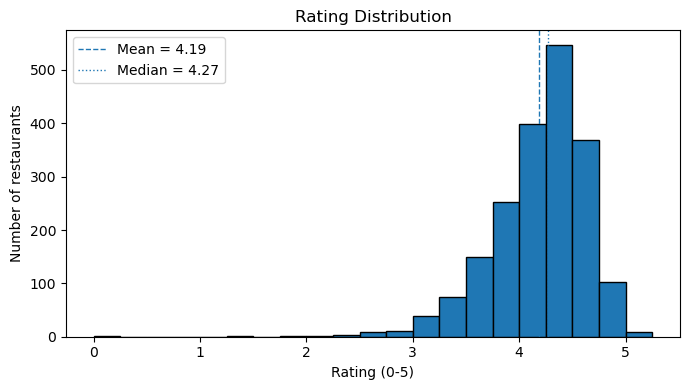

In [9]:
# distribution of rating
r = pd.to_numeric(gp_yelp["res_rating"], errors="coerce").dropna()

bins = np.arange(0, 5.5, 0.25)
plt.figure(figsize=(7, 4))
plt.hist(r, bins=bins, edgecolor="black")
plt.axvline(r.mean(), linestyle="--", linewidth=1, label=f"Mean = {r.mean():.2f}")
plt.axvline(r.median(), linestyle=":", linewidth=1, label=f"Median = {r.median():.2f}")

plt.title("Rating Distribution")
plt.xlabel("Rating (0-5)")
plt.ylabel("Number of restaurants")
plt.legend()
plt.tight_layout()
plt.show()

The distribution of ratings is heavily right-skewed, with most restaurants maintaining high scores. This suggests a high baseline of service quality across Chicago, likely driven by businesses actively managing their online reputations and encouraging satisfied customers to leave positive feedback.

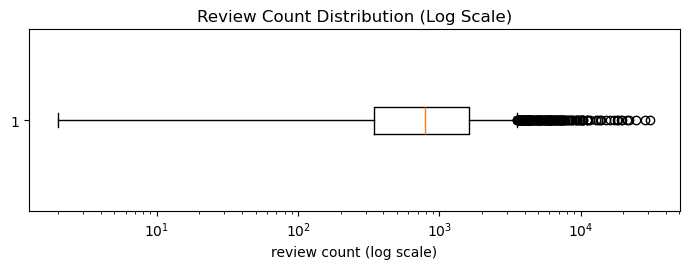

In [ ]:
# distribution of review count (log)
rc = pd.to_numeric(gp_yelp["res_review_count"], errors="coerce")
rc = rc[(rc.notna()) & (rc > 0)]

plt.figure(figsize=(7, 2.8))
plt.boxplot(rc, vert=False, showfliers=True)
plt.xscale("log")

plt.title("Review Count Distribution (Log Scale)")
plt.xlabel("review count (log scale)")
plt.tight_layout()
plt.show()

The distribution of merged review counts is highly right-skewed on a log scale, indicating that most restaurants have relatively moderate numbers of reviews while a small number have extremely large review volumes. This suggests inequality in online visibility and customer engagement across restaurants.

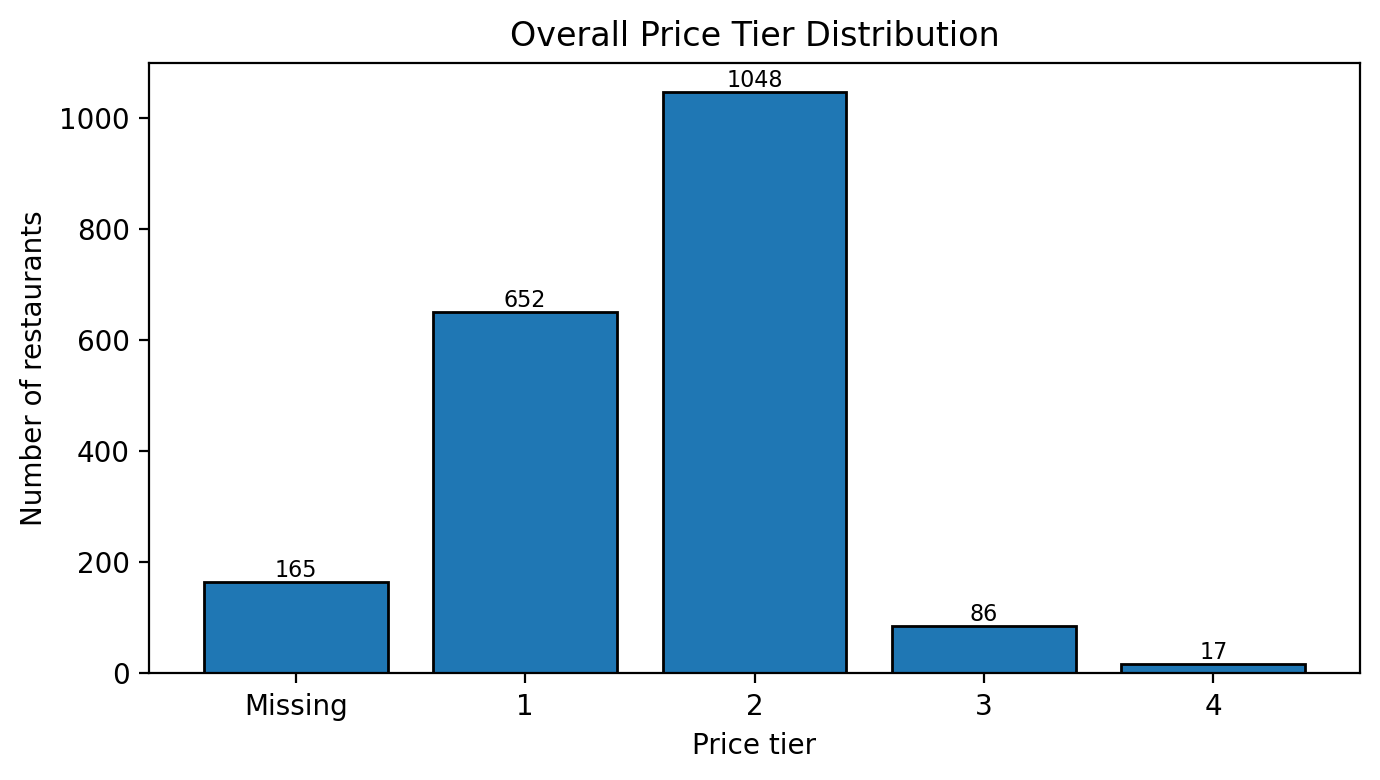

In [11]:
# price level distribution
p = pd.to_numeric(gp_yelp["res_price_level"], errors="coerce")

missing_ct = int(p.isna().sum())
ct1 = int((p == 1).sum())
ct2 = int((p == 2).sum())
ct3 = int((p == 3).sum())
ct4 = int((p == 4).sum())

x_labels = ["Missing", "1", "2", "3", "4"]
y_vals = [missing_ct, ct1, ct2, ct3, ct4]

plt.figure(figsize=(7, 4), dpi=200)
bars = plt.bar(x_labels, y_vals, edgecolor="black")

for b in bars:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h, f"{int(h)}",
                 ha="center", va="bottom", fontsize=8)

plt.title("Overall Price Tier Distribution")
plt.xlabel("Price tier")
plt.ylabel("Number of restaurants")
plt.tight_layout()
plt.show()

Yelp helps balance Google Places by providing an additional source of price and service data, allowing missing tiers or service signals in one platform to be filled by the other and reducing overall missingness in the merged dataset. The small number of tier-4 restaurants likely reflects both real scarcity and coverage issues: expensive venues are less common and may be less consistently labeled with price tiers, and they can also be harder to match across platforms due to branding differences and missing/ambiguous metadata.

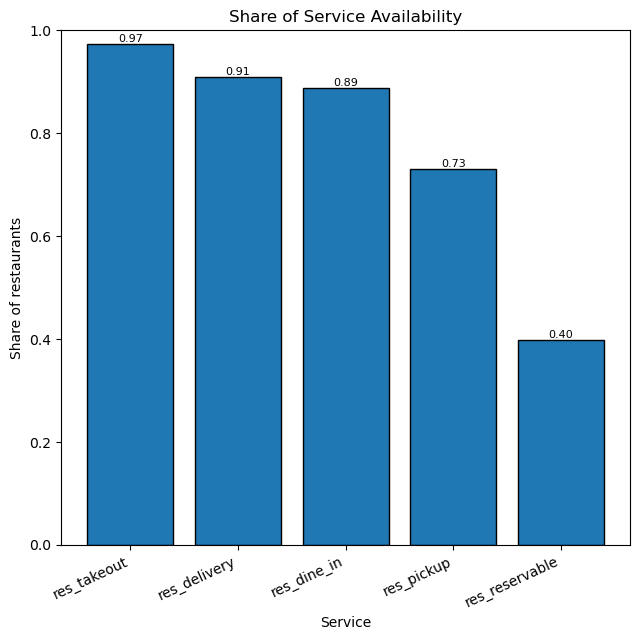

In [12]:
# service availability distribution
service_cols = ["res_takeout", "res_delivery", "res_dine_in", "res_reservable", "res_pickup"]
service_share = (gp_yelp[service_cols].apply(pd.to_numeric, errors="coerce").fillna(0).clip(0, 1).mean().sort_values(ascending=False))

plt.figure(figsize=(6.5, 6.5))
bars = plt.bar(service_share.index, service_share.values, edgecolor="black")

for b in bars:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.title("Share of Service Availability")
plt.xlabel("Service")
plt.ylabel("Share of restaurants")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

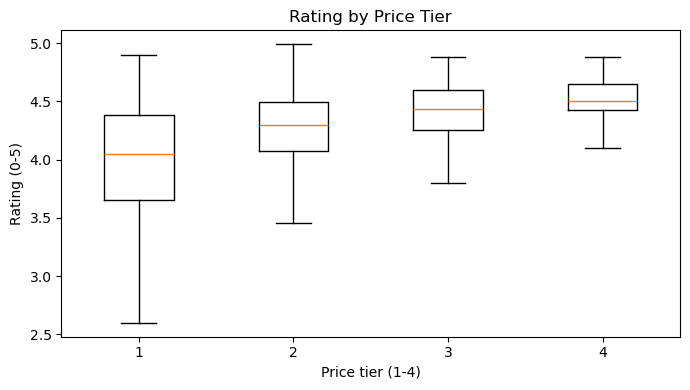

In [13]:
# rating by price tier
plot_df = gp_yelp[["res_rating", "res_price_level"]].copy()
plot_df["res_rating"] = pd.to_numeric(plot_df["res_rating"], errors="coerce")
plot_df["res_price_level"] = pd.to_numeric(plot_df["res_price_level"], errors="coerce")
plot_df = plot_df.dropna(subset=["res_rating", "res_price_level"])
plot_df = plot_df[plot_df["res_price_level"].isin([1, 2, 3, 4])]

groups = [plot_df.loc[plot_df["res_price_level"] == k, "res_rating"].values for k in [1, 2, 3, 4]]

plt.figure(figsize=(7, 4))
plt.boxplot(groups, tick_labels=["1", "2", "3", "4"], showfliers=False)

plt.title("Rating by Price Tier")
plt.xlabel("Price tier (1-4)")
plt.ylabel("Rating (0-5)")
plt.tight_layout()
plt.show()

The median restaurant rating increases steadily from price tier 1 to tier 4, suggesting that higher-priced restaurants tend to receive higher ratings on average. At the same time, lower-priced restaurants show greater variability in ratings, while higher-priced tiers have more tightly clustered and consistently high scores.

### Mapping

In [ ]:
bound["geometry"] = bound["the_geom"].apply(wkt.loads) # convert WKT geometry strings into shapely geometry objects
comm_areas = gpd.GeoDataFrame(bound, geometry="geometry", crs="EPSG:4326") # create a GeoDataFrame and set the geometry column with WGS84 coordinate reference system

# build GP point GeoDataFrame
gp_yelp_geo = gp_yelp.dropna(subset=["gp_latitude", "gp_longitude"]).copy()
gp_yelp_geo = gpd.GeoDataFrame(gp_yelp_geo,geometry=gpd.points_from_xy(gp_yelp_geo["gp_longitude"], gp_yelp_geo["gp_latitude"]),crs="EPSG:4326",)

# spatial join by assigning each restaurant to a community area
gp_yelp_join = gpd.sjoin(gp_yelp_geo, comm_areas[["AREA_NUMBE", "COMMUNITY", "geometry"]], how="left", predicate="within")

print("GP restaurants community area matched:", gp_yelp_join["AREA_NUMBE"].notna().sum())
print("GP restaurants outside polygons or missing:", gp_yelp_join["AREA_NUMBE"].isna().sum())

GP restaurants community area matched: 1968
GP restaurants outside polygons or missing: 0


In [15]:
# ensure restaurant names are consistent
acs["Community Area"] = acs["Community Area"].str.upper().str.strip()
comm_areas["COMMUNITY"] = comm_areas["COMMUNITY"].str.upper().str.strip()

# convert income columns to numeric
income_cols = ["Under $25,000", "$25,000 to $49,999", "$50,000 to $74,999", "$75,000 to $125,000", "$125,000 +"]

for c in income_cols:
    acs[c] = pd.to_numeric(acs[c].astype(str).str.replace(",", ""), errors="coerce")

# build an estimated income index using bin midpoints
midpoints = {
    "Under $25,000": 12500,
    "$25,000 to $49,999": 37500,
    "$50,000 to $74,999": 62500,
    "$75,000 to $125,000": 100000,
    "$125,000 +": 218750 # manually set midpoints = 1.75* lower bound
}

acs["income_total"] = acs[income_cols].sum(axis=1)
acs["income_index"] = (
    acs["Under $25,000"] * midpoints["Under $25,000"] +
    acs["$25,000 to $49,999"] * midpoints["$25,000 to $49,999"] +
    acs["$50,000 to $74,999"] * midpoints["$50,000 to $74,999"] +
    acs["$75,000 to $125,000"] * midpoints["$75,000 to $125,000"] +
    acs["$125,000 +"] * midpoints["$125,000 +"]
) / acs["income_total"]

# keep the columns we need
acs_ses = acs[["Community Area", "income_index"]].copy()

# merge SES onto community boundaries 
comm_ses = comm_areas.merge(acs_ses, left_on="COMMUNITY", right_on="Community Area", how="left")

In [ ]:
# helper function to split long names into two lines for better display in plots or labels
def wrap_name(name):
    words = str(name).split()
    if len(words) >= 2:
        mid = len(words) // 2
        return " ".join(words[:mid]) + "\n" + " ".join(words[mid:])
    return str(name)

# helper function to add labels (make community areas name 2-line, bold, white text, and black outline)
def add_comm_labels(ax, gdf, name_col="COMMUNITY", fontsize=5.5, alpha=0.95, stroke_lw=1):
    label_gdf = gdf.copy()
    label_gdf["label_pt"] = label_gdf.geometry.representative_point()
    for x, y, name in zip(label_gdf["label_pt"].x, label_gdf["label_pt"].y, label_gdf[name_col]):
        txt = ax.text(x, y, wrap_name(name), fontsize=fontsize, color="white", ha="center", va="center", fontweight="bold", alpha=alpha)
        txt.set_path_effects([pe.Stroke(linewidth=stroke_lw, foreground="black"), pe.Normal()])

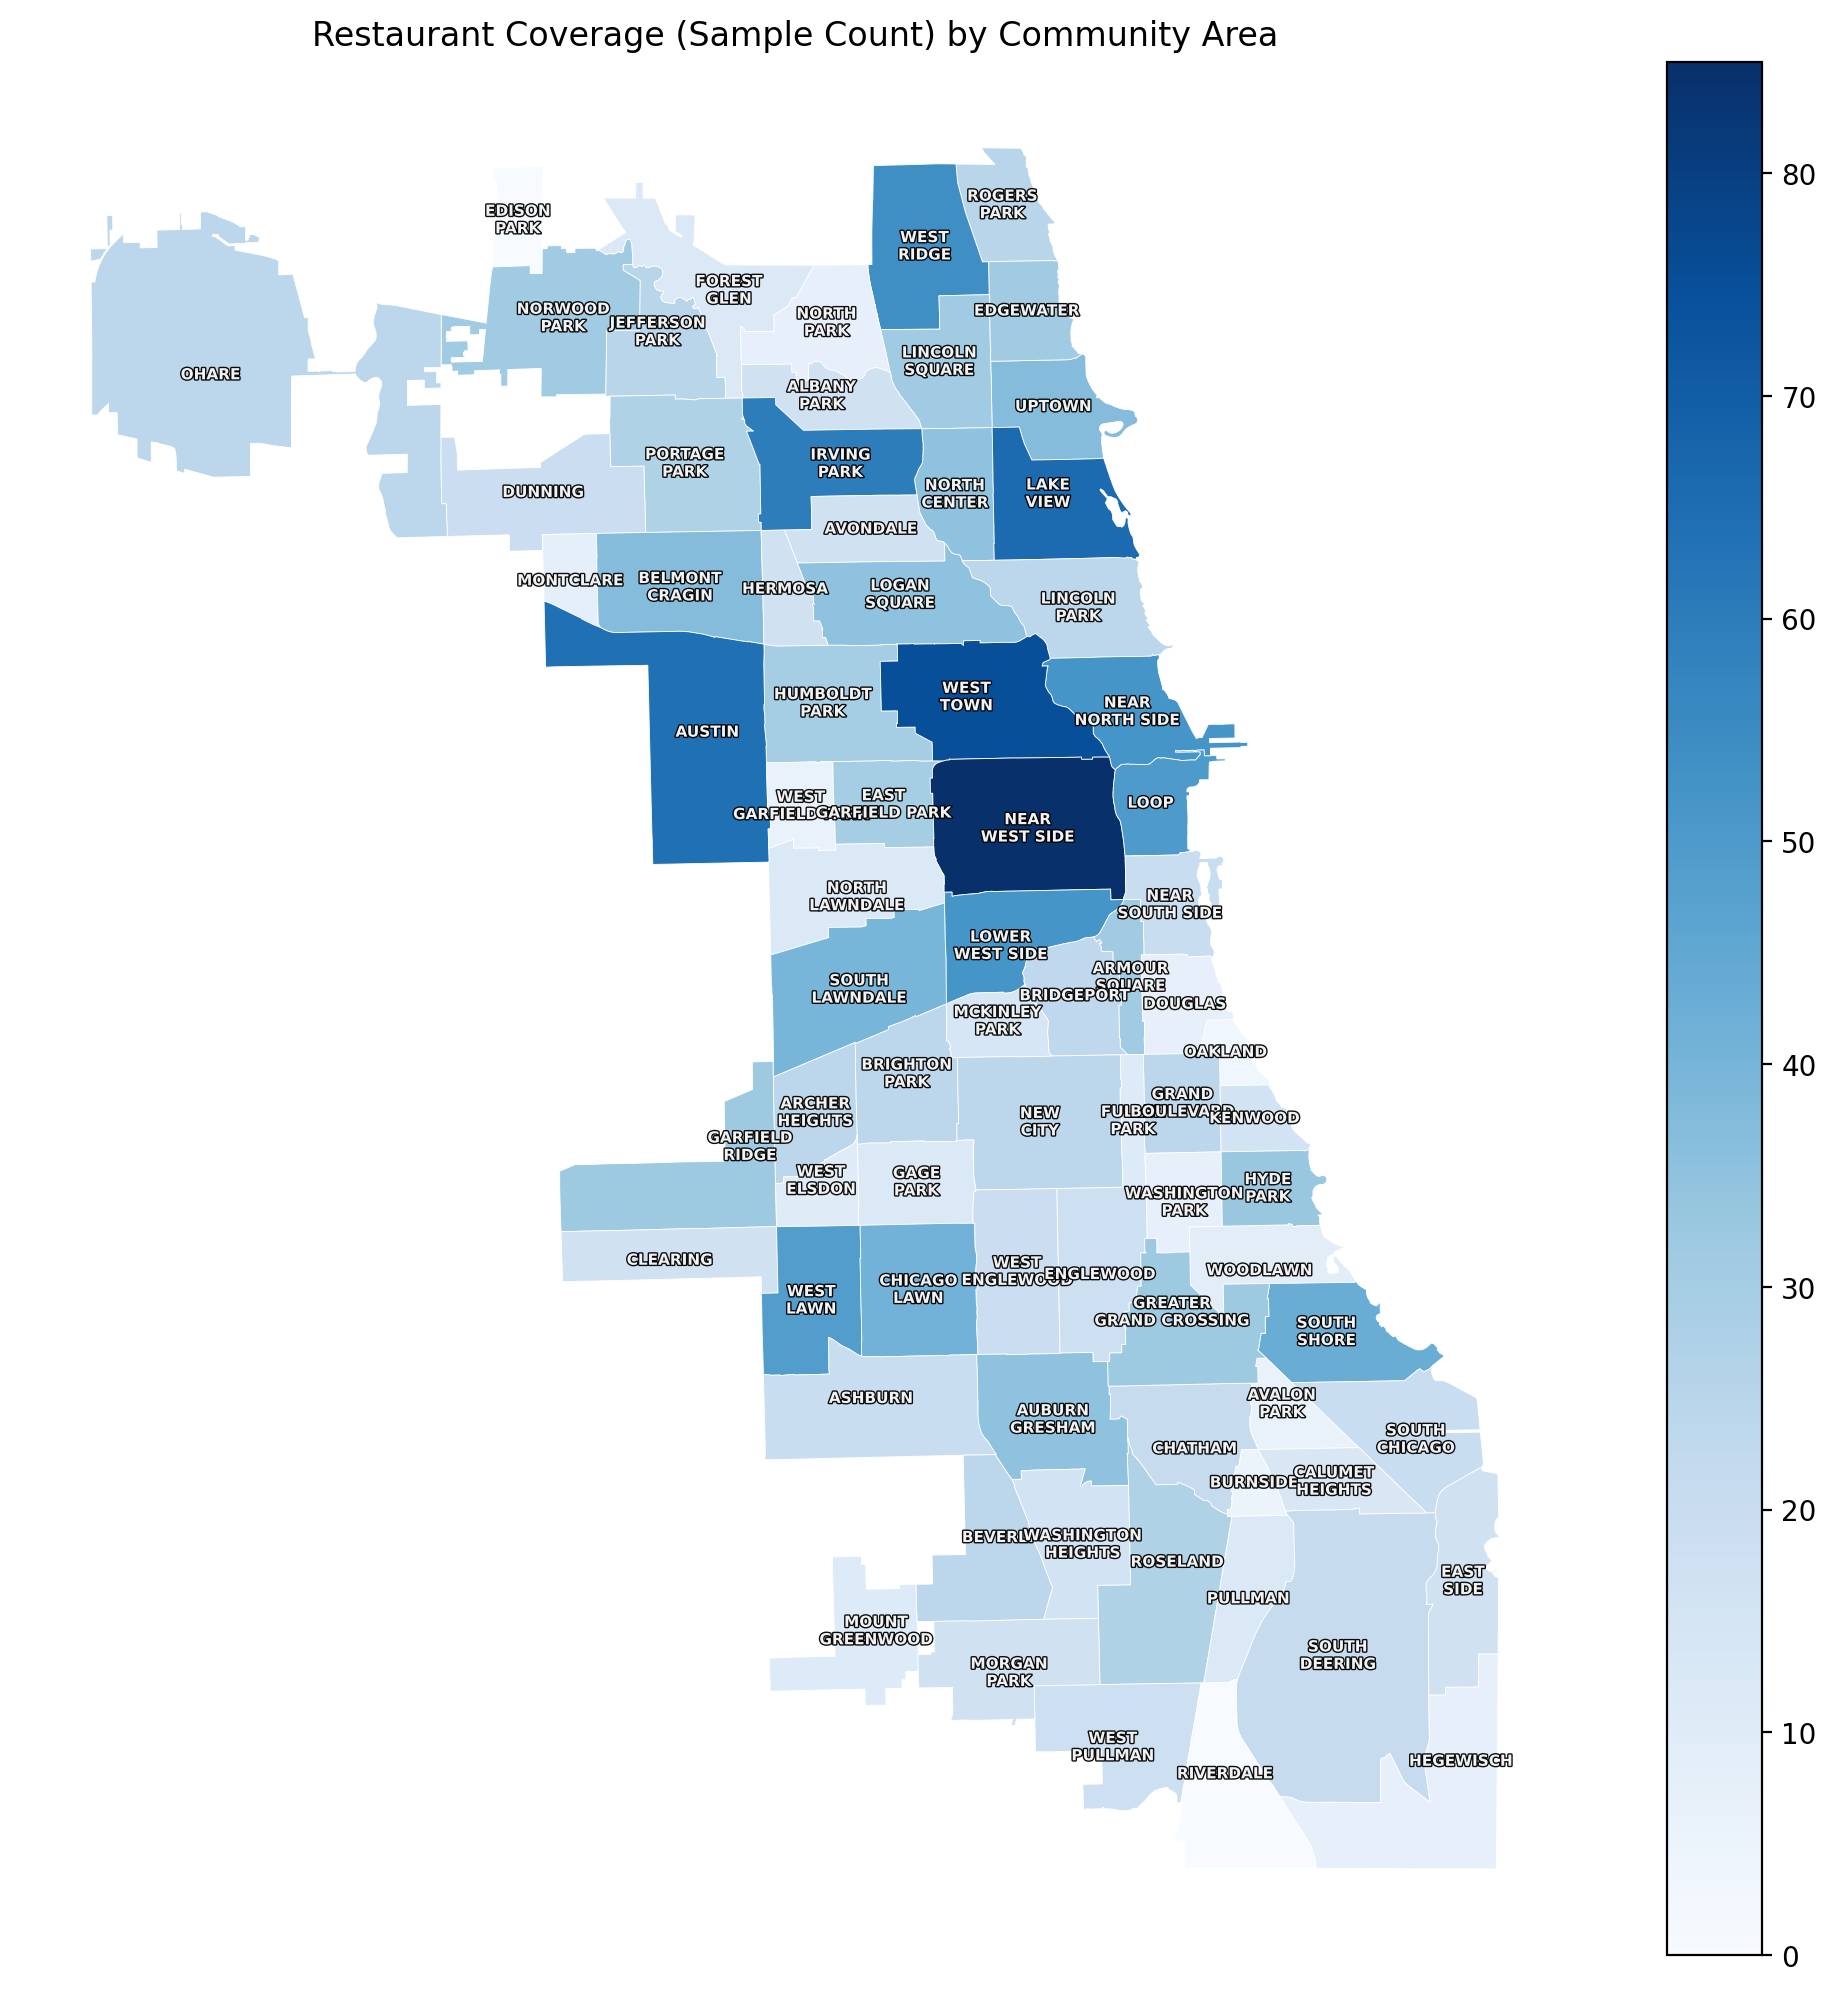

In [17]:
# Restaurant Coverage (Sample Count) by Community Area
# build GeoDataFrame for restaurants
gp_geo = gpd.GeoDataFrame(gp_yelp, geometry=gpd.points_from_xy(gp_yelp["gp_query_lon"], gp_yelp["gp_query_lat"]), crs="EPSG:4326").to_crs(comm_areas.crs)

# spatial join to assign each restaurant to a community area
gp_join = gpd.sjoin(gp_geo, comm_areas[["AREA_NUMBE", "COMMUNITY", "geometry"]], how="left", predicate="within")

# count restaurants per community area and merge back
coverage = gp_join.groupby("AREA_NUMBE").size().reset_index(name="n_restaurants_sample")
comm_cov = comm_areas.merge(coverage, on="AREA_NUMBE", how="left")
comm_cov["n_restaurants_sample"] = comm_cov["n_restaurants_sample"].fillna(0).astype(int)

# plot choropleth
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)
comm_cov.plot(ax=ax, column="n_restaurants_sample", legend=True, cmap="Blues", edgecolor="white", linewidth=0.3)
add_comm_labels(ax, comm_cov, fontsize=5.5, alpha=0.95, stroke_lw=1)
ax.set_title("Restaurant Coverage (Sample Count) by Community Area")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [ ]:
print("comm_areas CRS:", comm_areas.crs)
print("gp_geo CRS:", gp_geo.crs)
print("joined matched:", gp_join["AREA_NUMBE"].notna().sum())
print("joined unmatched:", gp_join["AREA_NUMBE"].isna().sum())

comm_areas CRS: EPSG:4326
gp_geo CRS: EPSG:4326
joined matched: 1968
joined unmatched: 0


The map suggests that the restaurant sample provides strong and reasonably representative coverage across Chicago community areas. Counts are highest in central and North Side neighborhoods (for example, Near West Side, West Town, Loop, Lake View, and Near North Side) and also in a few non-central areas such as West Lawn and South Shore, which likely reflects  higher restaurant density in these locations rather than sampling artifacts. While some outlying South and far West Side areas have fewer observations, the overall spatial pattern aligns with expected clustering of restaurants in busier commercial corridors. This indicates that the dataset offers adequate coverage for neighborhood-level analysis.

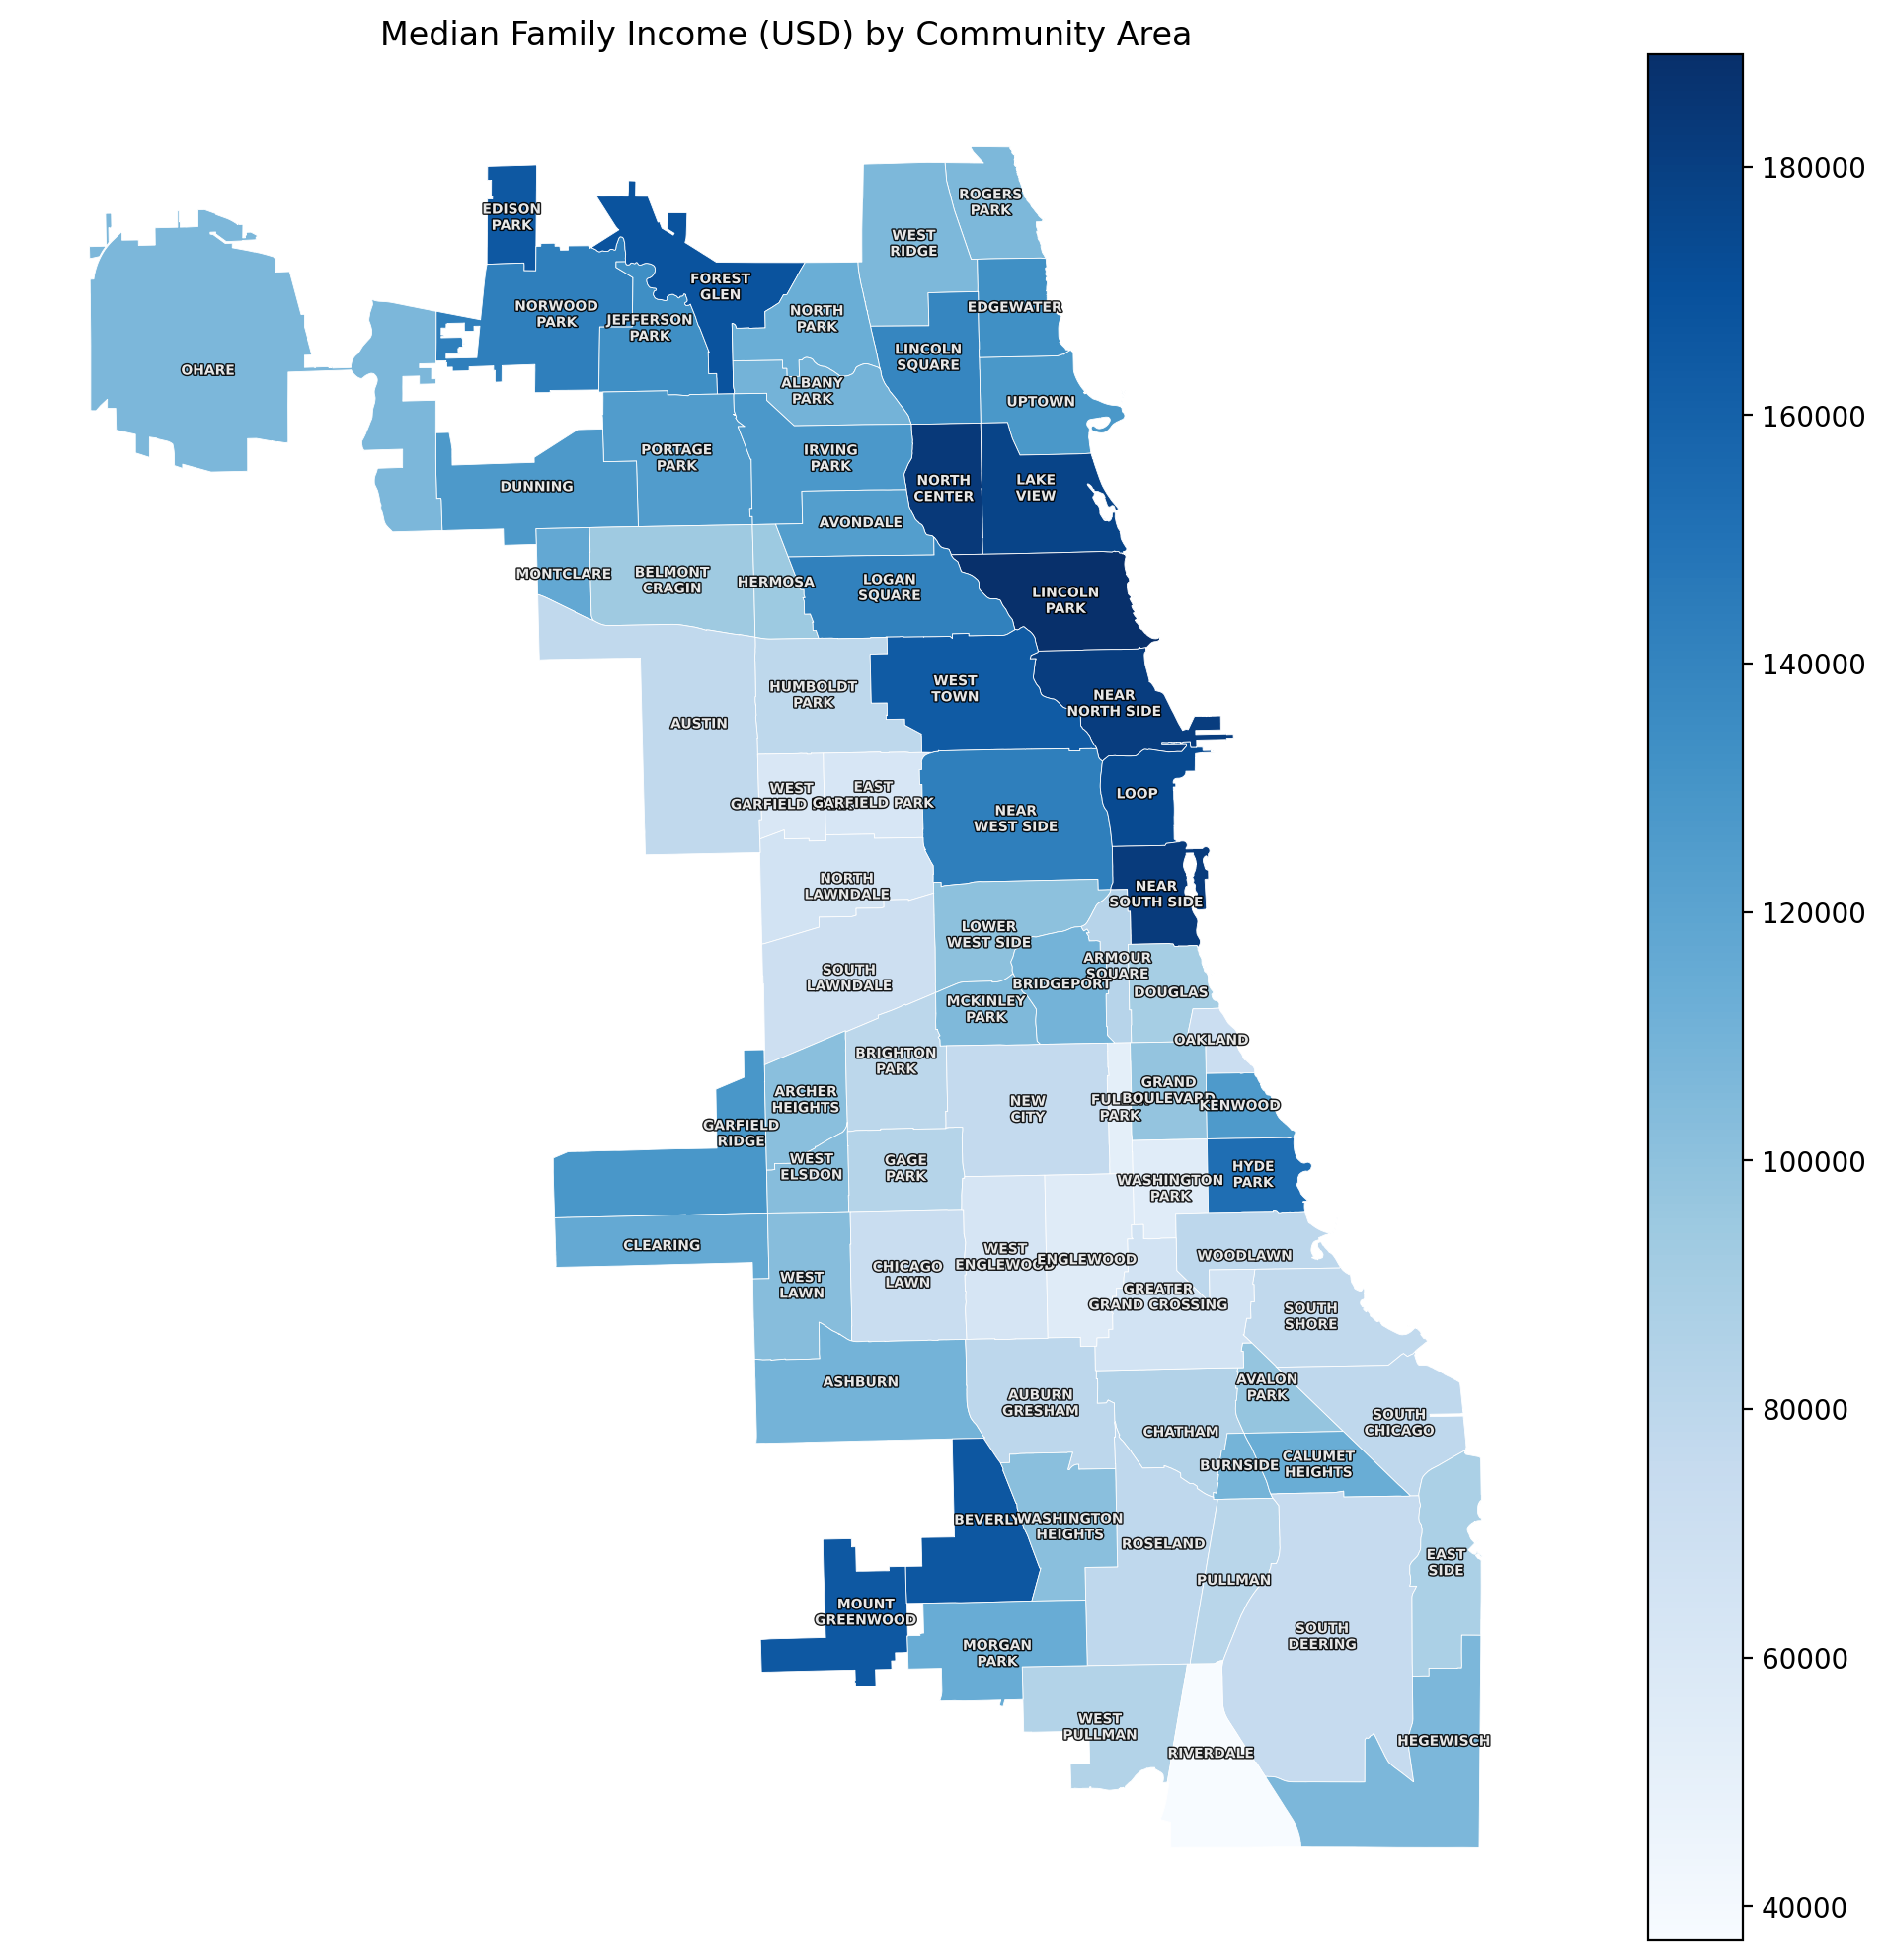

In [19]:
# Median Family Income (USD) by Community Area
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)
comm_ses.plot(ax=ax, column="income_index", legend=True, cmap="Blues", edgecolor="white", linewidth=0.3)
add_comm_labels(ax, comm_areas, fontsize=5, alpha=0.9, stroke_lw=1)
ax.set_title("Median Family Income (USD) by Community Area")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Median family income varies across community areas, with higher-income neighborhoods concentrated in the North Side and near-lakefront/central areas (including Lincoln Park, Lake View, Near North Side, and the Loop). Lower median incomes are more prevalent across much of the South and West Sides, forming a clear spatial gradient in socioeconomic conditions.

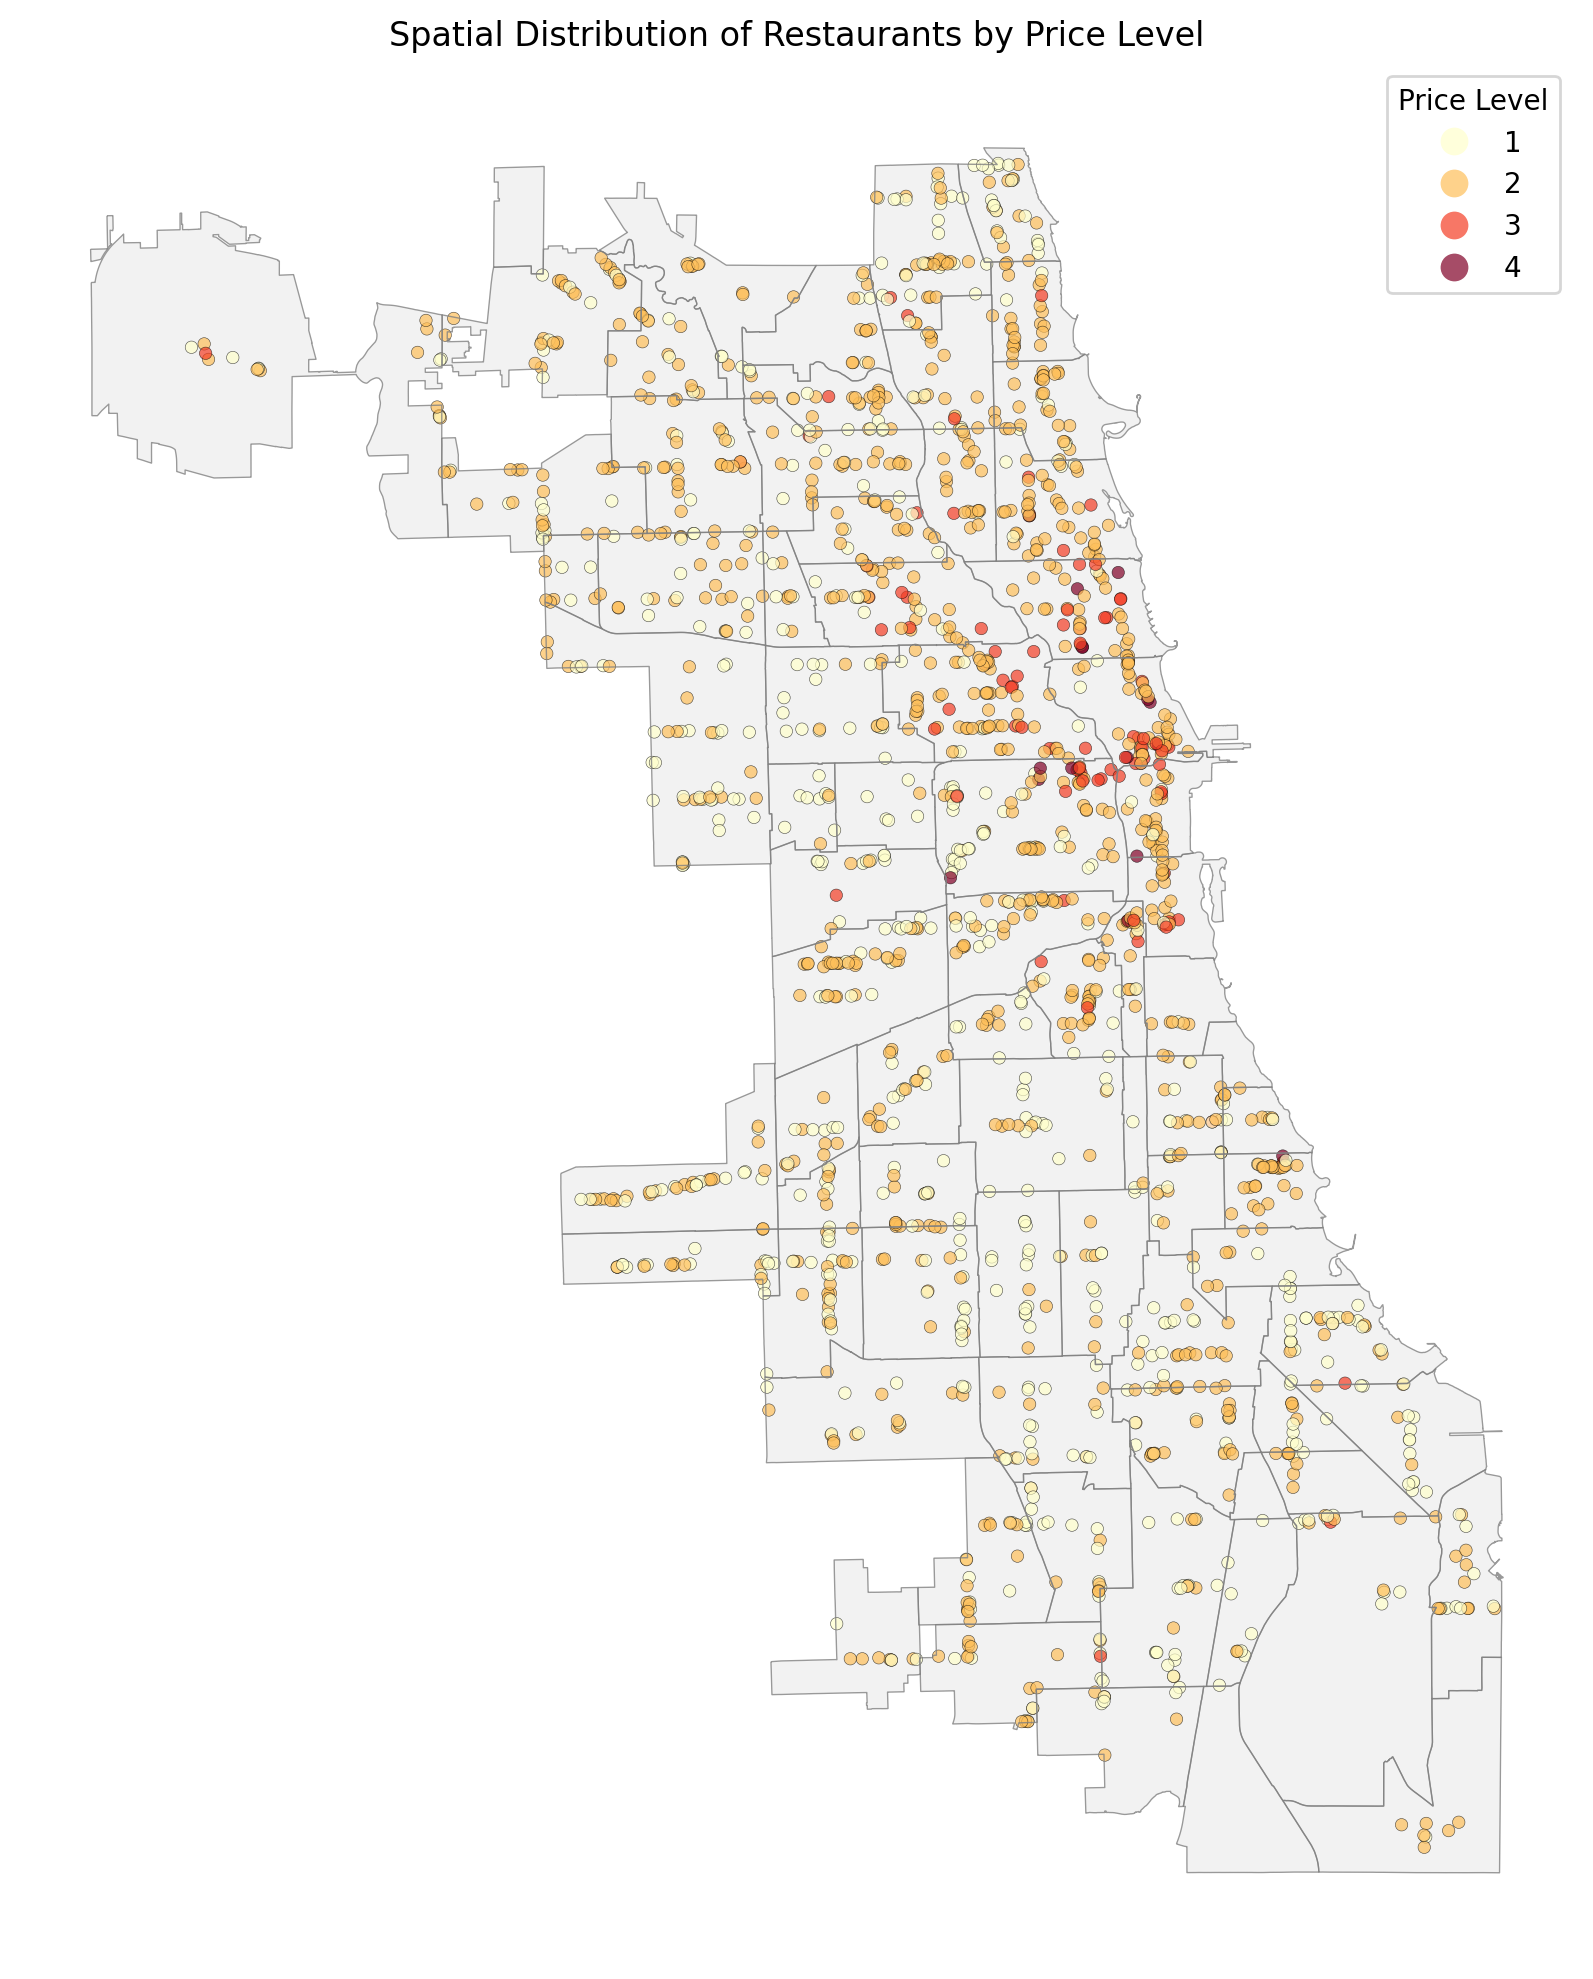

In [20]:
# spatial distribution of restaurants by price level
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)

comm_areas.plot(ax=ax, color="#f2f2f2", edgecolor="white", linewidth=0.6)
comm_areas.boundary.plot(ax=ax, color="grey", linewidth=0.5, alpha=0.8) 

# plot points
gp_yelp_plot = gp_yelp_join.dropna(subset=["res_price_level"]).copy()
gp_yelp_plot["price_cat"] = gp_yelp_plot["res_price_level"].astype(int).astype(str)

# use Yellow-Orange-Red color for intensity scale
cmap = plt.get_cmap("YlOrRd", 4)

gp_yelp_plot.plot(ax=ax, column="price_cat", cmap=cmap, categorical=True, legend=True, markersize=20, alpha=0.7, edgecolor="black", 
                  linewidth=0.2, legend_kwds={'title': "Price Level", 'loc': 'upper right'})

ax.set_title("Spatial Distribution of Restaurants by Price Level")
ax.set_axis_off()
plt.tight_layout()
plt.show()

This graph shows clear geographic clustering across Chicago. Higher-priced restaurants (levels 3 and 4) are concentrated in central and North Side neighborhoods, particularly around the Loop, Near North Side, and nearby lakefront areas, whereas lower-priced establishments (levels 1 and 2) are more widely dispersed throughout the city.This pattern suggests that more expensive dining options cluster in high-activity, centrally located areas with strong commercial presence, while more affordable restaurants are broadly distributed across community areas.

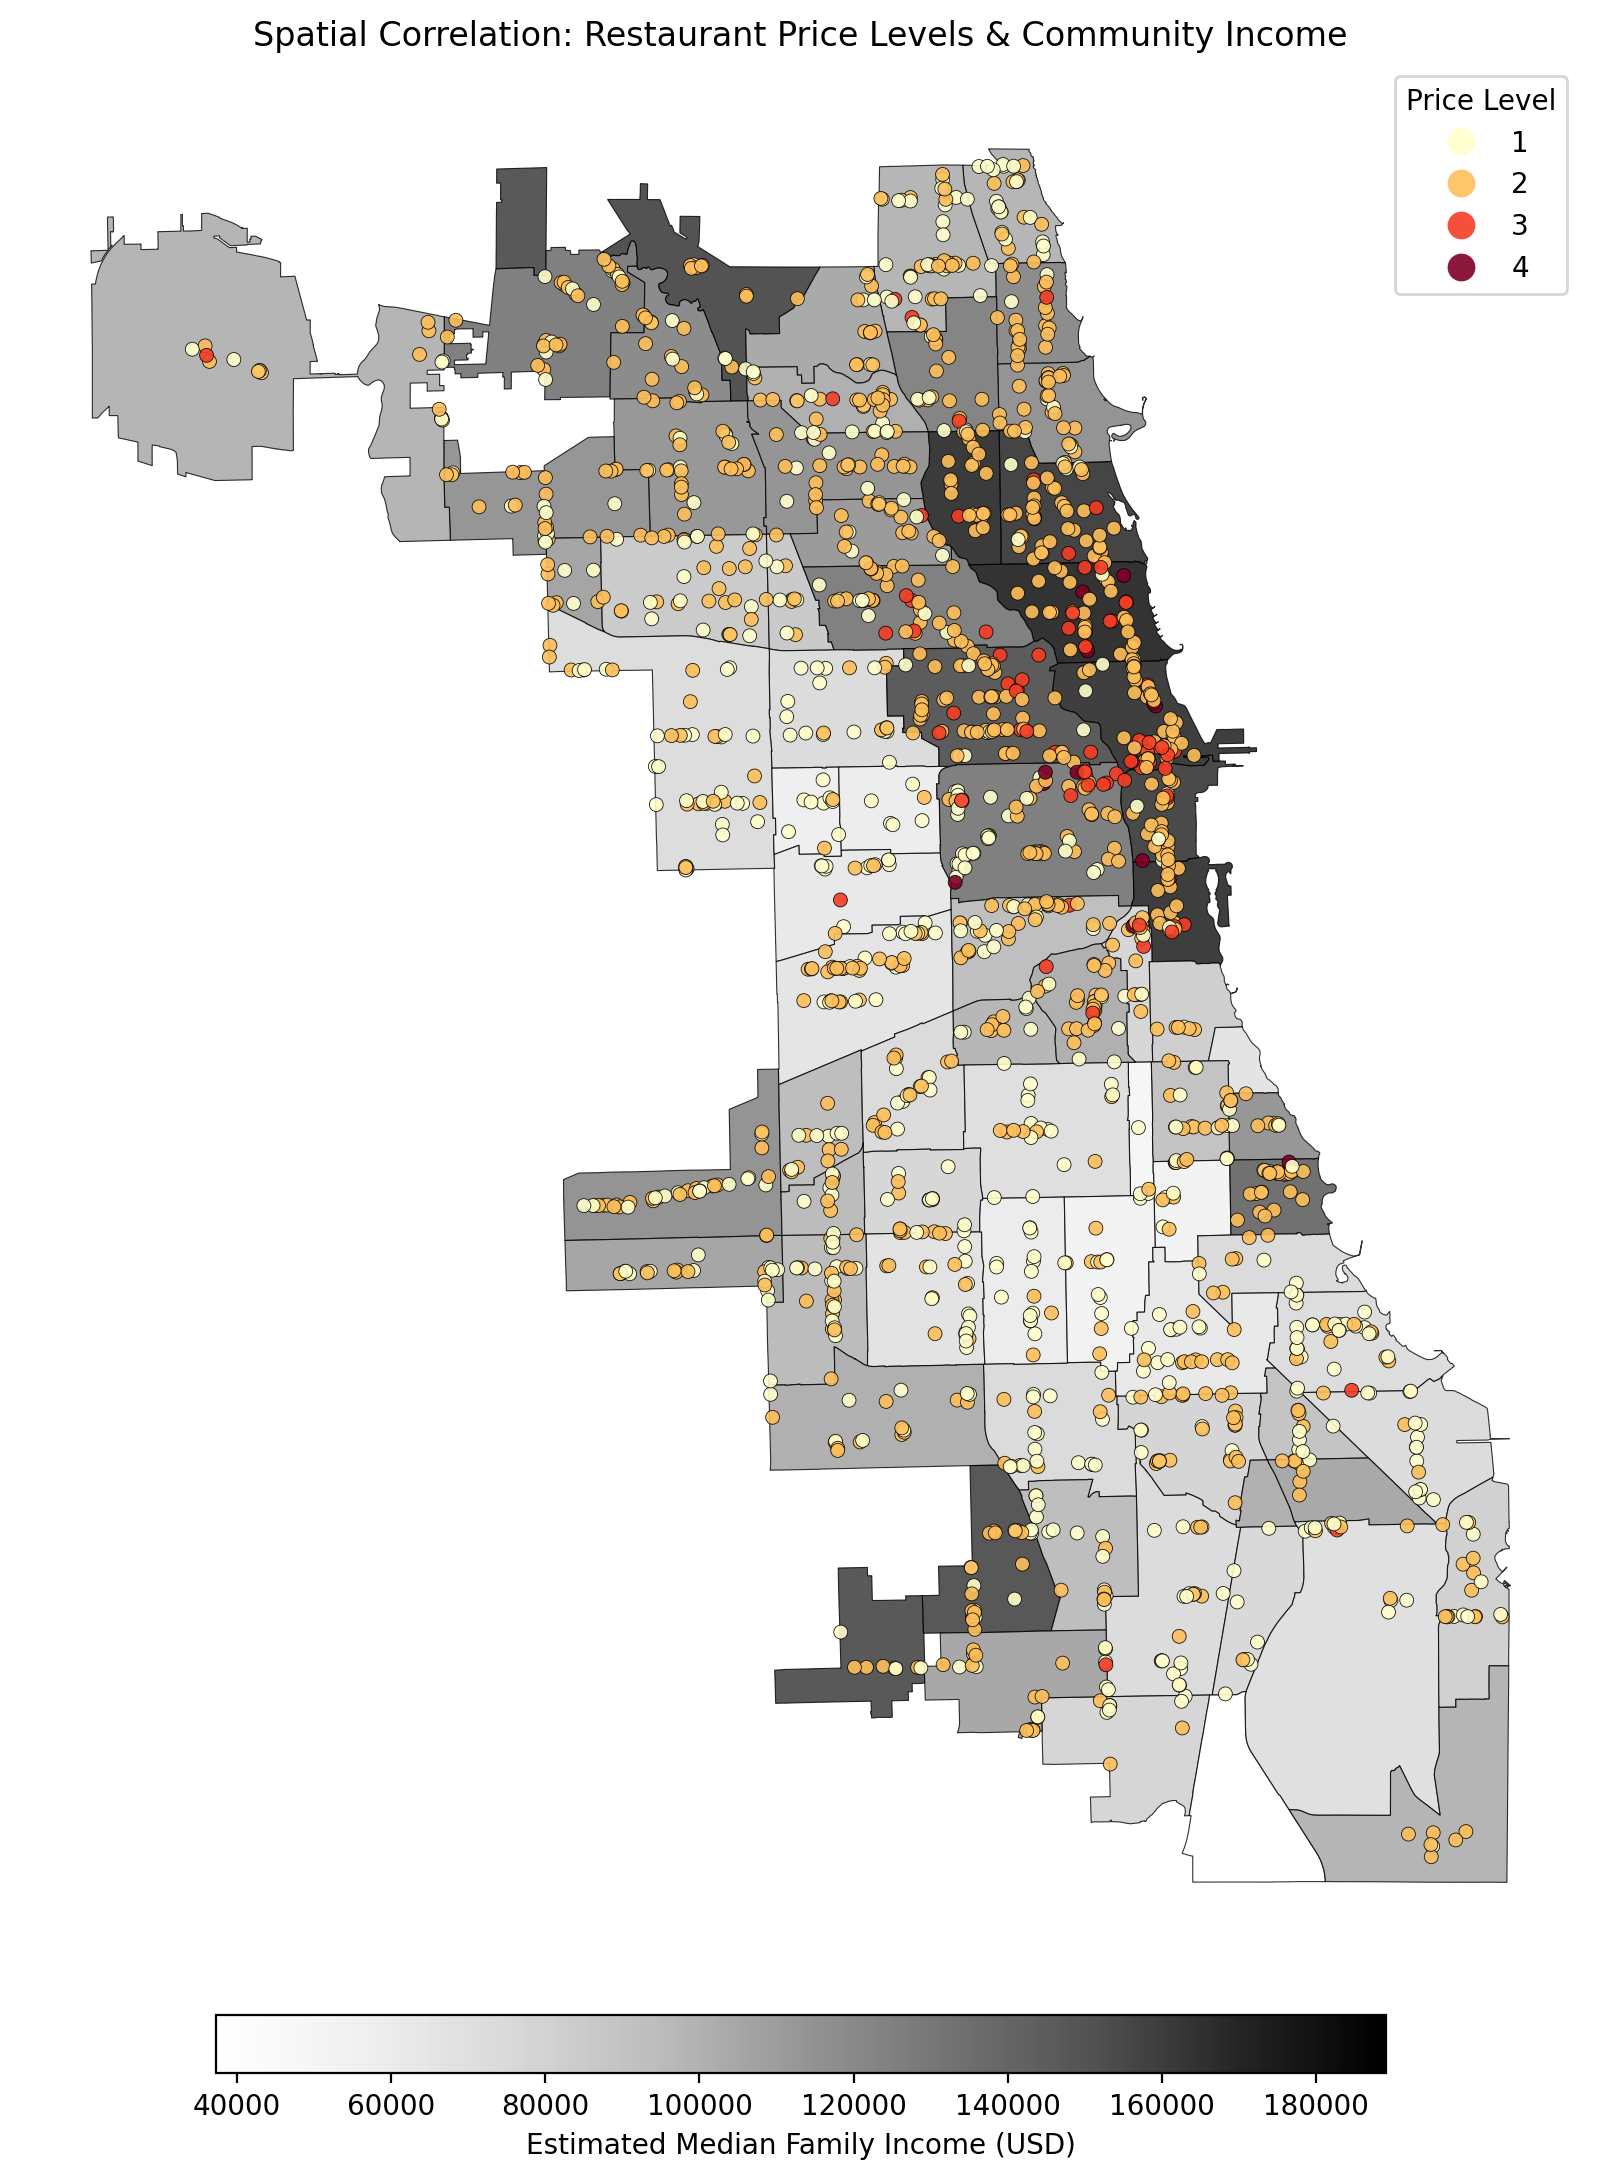

In [21]:
# combine information in previous two figures to show Spatial Correlation: Price Levels vs. Community Income
# Background: Median Family Income gradient; Points: Restaurant Price Levels

fig, ax = plt.subplots(figsize=(12, 12), dpi=200)

# base layer is Income gradient with horizontal colorbar
comm_ses.plot(ax=ax, column="income_index", cmap="Greys", legend=True,
              legend_kwds={'label': "Estimated Median Family Income (USD)", 'orientation': "horizontal", 'pad': 0.02, 'shrink': 0.5},
              edgecolor="black", linewidth=0.4, alpha=0.8)

# points layer is restaurant price levels
gp_yelp_plot = gp_yelp_join.dropna(subset=["res_price_level"]).copy()
gp_yelp_plot["price_cat"] = gp_yelp_plot["res_price_level"].astype(int).astype(str)

cmap_price = plt.get_cmap("YlOrRd", 4)

gp_yelp_plot.plot(ax=ax, column="price_cat", cmap=cmap_price, categorical=True, legend=True, markersize=25, alpha=0.9, edgecolor="black", linewidth=0.3,
                  legend_kwds={'title': "Price Level", 'loc': 'upper right'})

ax.set_title("Spatial Correlation: Restaurant Price Levels & Community Income")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In this study, I measure neighborhood socioeconomic status using an income_index, a continuous indicator constructed from American Community Survey (ACS) income-bin distributions. Because the ACS reports the number of households in predefined income brackets (like “Under $25,000,” “$25,000 to $49,999,” etc.) rather than a single average income value, I summarize each community area’s overall income level by computing a weighted average: I multiply the household count in each bracket by that bracket’s midpoint, sum across brackets, and divide by the total number of households. This produces an estimated neighborhood income level that reflects the full income distribution (it is an approximation rather than the official census median income). 
For visualization, I then group neighborhoods into income quintiles based on the income_index by ranking all neighborhoods and splitting them into five equal-sized groups, each representing roughly 20 percent of neighborhoods: Q1 contains the lowest-income neighborhoods in the sample, Q5 contains the highest-income neighborhoods, and Q2–Q4 represent intermediate levels. These quintiles are relative rankings within Chicago rather than fixed income categories, and they help ensure that each group has a comparable number of observations for clearer comparisons in plots.

/var/folders/lm/wvqh87x93hs7jfg66h8zq72c0000gn/T/ipykernel_14629/2783221816.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_share["share"] = price_share["n"] / price_share.groupby("income_quintile")["n"].transform("sum")


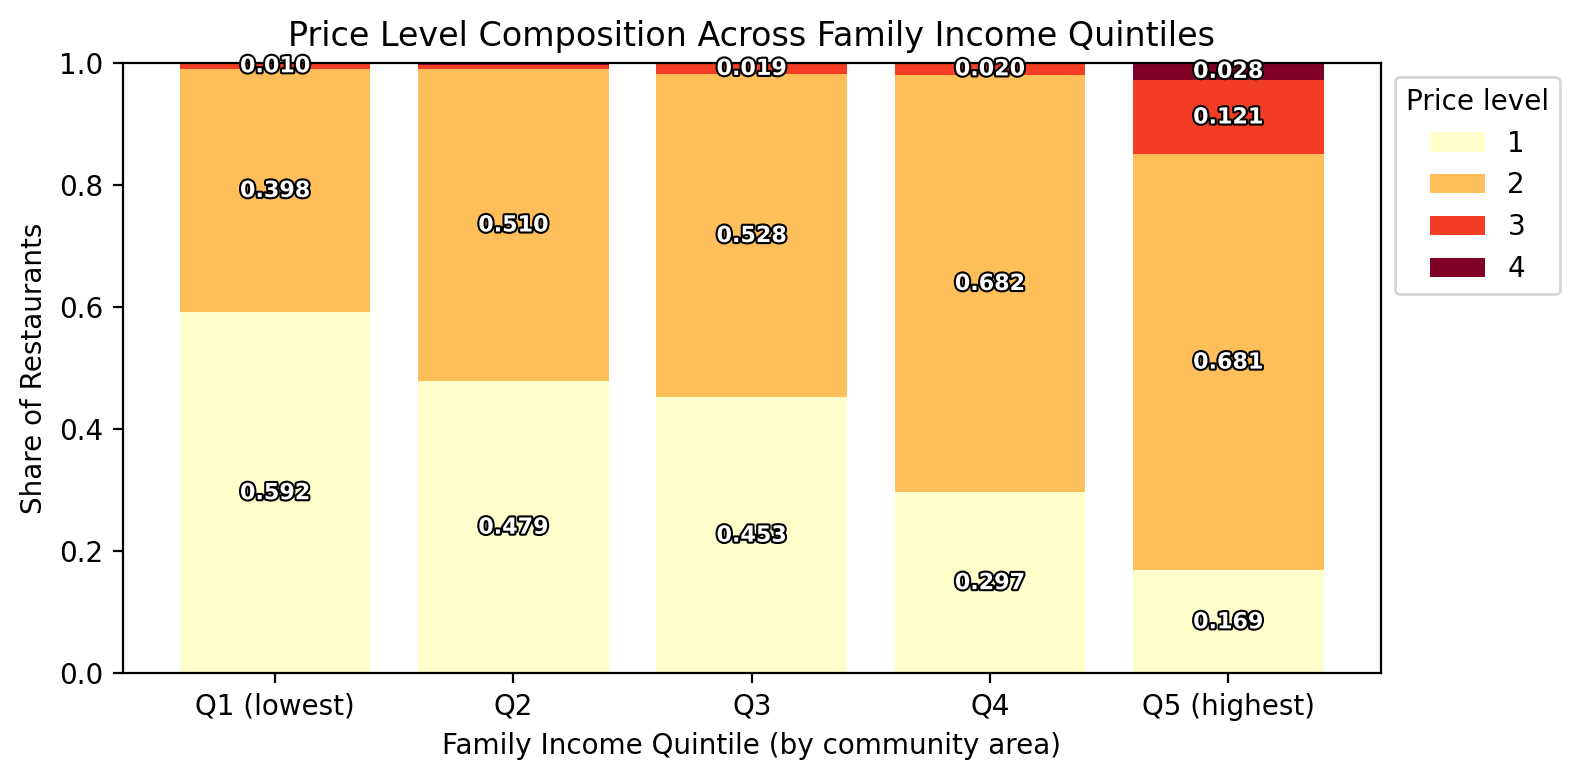

In [ ]:
# Price Level Composition Across Family Income Quintiles
price_col = "res_price_level"

# assign each community area to a family income Quintile (5 bins)
comm_ses_q = comm_ses[["AREA_NUMBE","income_index"]].dropna().copy()
comm_ses_q["income_quintile"] = pd.qcut(comm_ses_q["income_index"], q=5, labels=["Q1 (lowest)","Q2","Q3","Q4","Q5 (highest)"], duplicates="drop")

# merge quintile labels onto restaurant-level data
gp_price = gp_yelp_join.merge(comm_ses_q[["AREA_NUMBE","income_quintile"]], on="AREA_NUMBE", how="left").dropna(subset=["income_quintile", price_col]).copy()
gp_price[price_col] = pd.to_numeric(gp_price[price_col], errors="coerce")
gp_price = gp_price.dropna(subset=[price_col]).copy()
gp_price[price_col] = gp_price[price_col].astype(int)

# compute share of each price level within each quintile
price_share = gp_price.groupby(["income_quintile", price_col], observed=False).size().reset_index(name="n")
price_share["share"] = price_share["n"] / price_share.groupby("income_quintile")["n"].transform("sum")

# pivot for stacked bar
share_df = price_share.pivot(index="income_quintile", columns=price_col, values="share").fillna(0).reindex(columns=[1,2,3,4]).reindex(["Q1 (lowest)","Q2","Q3","Q4","Q5 (highest)"])
cmap = plt.get_cmap("YlOrRd", 4)
colors = [cmap(i) for i in range(4)]

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
bottom = np.zeros(len(share_df))
x = np.arange(len(share_df.index))

for idx, lvl in enumerate(share_df.columns):
    vals = share_df[lvl].values
    bars = ax.bar(x, vals, bottom=bottom, label=str(lvl), color=colors[idx])
    for i, b in enumerate(bars):
        v = vals[i]
        if v >= 0.01:
            t = ax.text(b.get_x() + b.get_width()/2, bottom[i] + v/2, f"{v:.3f}", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
            t.set_path_effects([pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()])
    bottom += vals

ax.set_xticks(x); ax.set_xticklabels(share_df.index)
ax.set_xlabel("Family Income Quintile (by community area)")
ax.set_ylabel("Share of Restaurants")
ax.set_title("Price Level Composition Across Family Income Quintiles")
ax.legend(title="Price level", loc="upper left")
ax.legend(title="Price level", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

The composition of restaurant price levels varies systematically across neighborhood income quintiles. In lower-income areas Q1, level 1 restaurants make up the majority of restaurants, whereas in higher-income areas Q5, the share of level 1 restaurants declines substantially and the proportion of higher price tiers (levels 3 and 4) increases. Meanwhile, level 2 restaurants constitute a large share across all quintiles but become more dominantly present in upper-income neighborhoods. Overall, this figure illustrates a clear socioeconomic gradient in restaurant pricing, with higher-income communities hosting a larger proportion of mid-end to high-priced restaurants.

In [23]:
# check quintile ranges 
comm_ses_q = comm_ses[["AREA_NUMBE","income_index"]].dropna().copy()
quintile_series, bins = pd.qcut(comm_ses_q["income_index"], q=5, labels=["Q1 (lowest)","Q2","Q3","Q4","Q5 (highest)"], duplicates="drop", retbins=True)
comm_ses_q["income_quintile"] = quintile_series

labels = ["Q1","Q2","Q3","Q4","Q5"]
for i in range(len(bins)-1):
    print(f"{labels[i]}: ${bins[i]:,.0f} to ${bins[i+1]:,.0f}")

Q1: $37,242 to $77,932
Q2: $77,932 to $95,831
Q3: $95,831 to $109,832
Q4: $109,832 to $138,031
Q5: $138,031 to $189,040


Higher-priced restaurants (price level 3–4) are rare overall, but they are concentrated in the highest-income quintile.

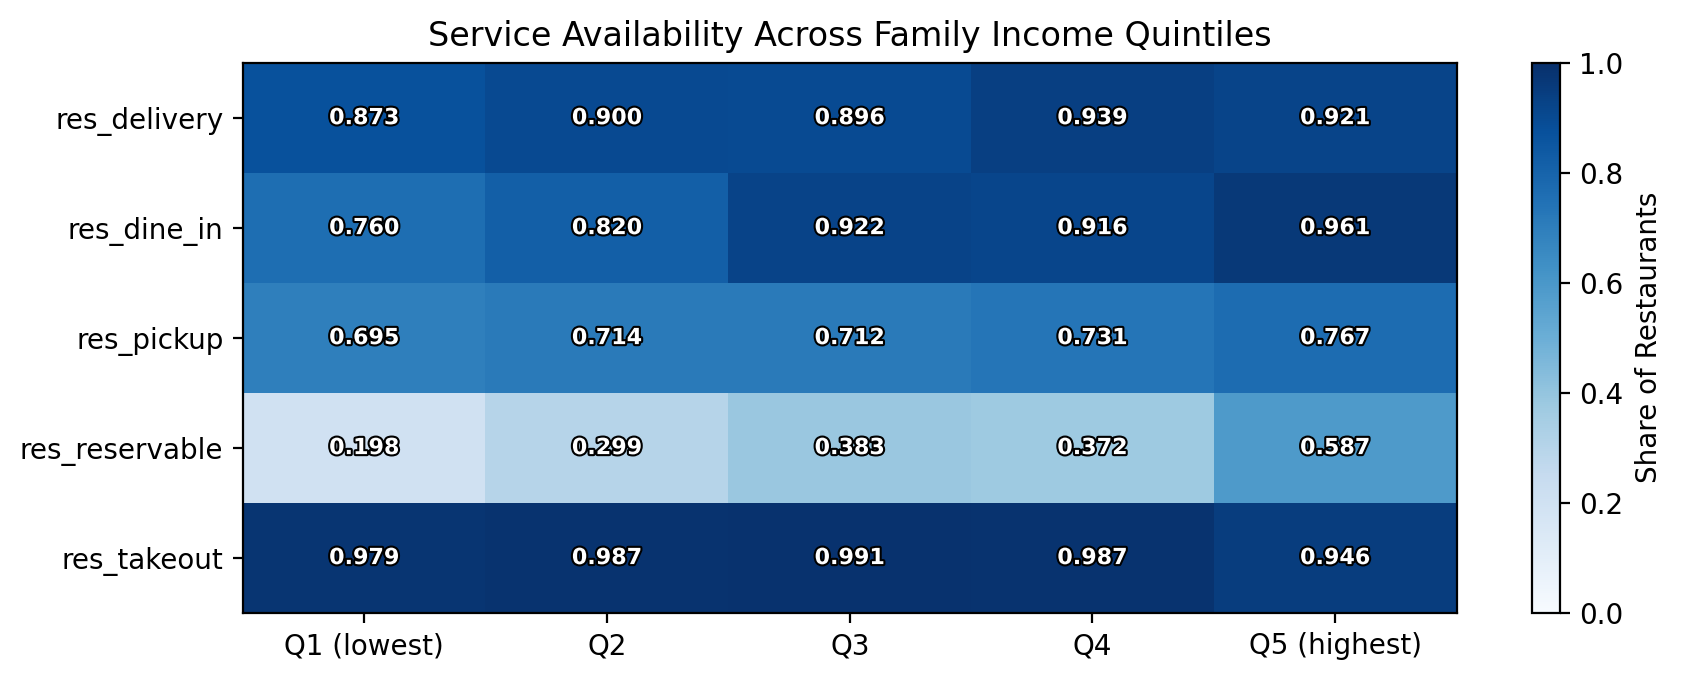

In [ ]:
# Service Availability Across Family Income Quintiles
# Note: service fields are coded as 0/1 in the dataset; since missing values were filled as 0 in scraping, these shares should be interpreted as lower-bound estimates
service_cols = ["res_pickup", "res_takeout", "res_delivery", "res_dine_in", "res_reservable"]

# merge quintile labels onto restaurant data
gp_svc = gp_yelp_join.merge(comm_ses_q[["AREA_NUMBE", "income_quintile"]], on="AREA_NUMBE", how="left").dropna(subset=["income_quintile"]).copy()

# compute service availability share + sample size by quintile
svc_summary = (gp_svc.groupby("income_quintile", observed=False).agg(
    n_restaurants=("income_quintile", "size"),
    res_pickup=("res_pickup", "mean"),
    res_takeout=("res_takeout", "mean"),
    res_delivery=("res_delivery", "mean"),
    res_dine_in=("res_dine_in", "mean"),
    res_reservable=("res_reservable", "mean")
).reset_index())

# reshape for heatmap
svc_share = svc_summary.melt(id_vars=["income_quintile", "n_restaurants"], value_vars=service_cols, var_name="service", value_name="share")
heat_df = svc_share.pivot(index="service", columns="income_quintile", values="share")
n_by_q = svc_summary.set_index("income_quintile")["n_restaurants"]

# heatmap
fig, ax = plt.subplots(figsize=(9, 3.5), dpi=200)
im = ax.imshow(heat_df.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)

# axis labels
ax.set_xticks(range(len(heat_df.columns)))
ax.set_xticklabels([f"{q}" for q in heat_df.columns])
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("Service Availability Across Family Income Quintiles")

# add value labels
for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        t = ax.text(j, i, f"{heat_df.values[i, j]:.3f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        t.set_path_effects([pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()])

cbar = plt.colorbar(im, ax=ax) # colorbar
cbar.set_label("Share of Restaurants")

plt.tight_layout()
plt.show()

Because service fields are coded as 0/1 in the provided dataset and missing values were filled as 0, the plotted shares should be interpreted as conservative lower-bound estimates of service availability.

We can observe that service availability differs across income quintiles, with more formal dining features becoming increasingly common in higher-income neighborhoods. While takeout and delivery are nearly universal across all SES levels, the share of restaurants offering dine-in service and especially reservations rises substantially from Q1 to Q5, indicating that affluent/commercial areas are more likely to host restaurants with structured, full-service formats. This pattern suggests that restaurants in higher-income areas provide more comprehensive service formats.

In [25]:
# SES + Restaurant Type Analysis
# merge SES data 
ses_lookup = comm_ses[["AREA_NUMBE", "income_index"]].dropna(subset=["AREA_NUMBE"]).copy()
ses_lookup["AREA_NUMBE"] = pd.to_numeric(ses_lookup["AREA_NUMBE"], errors="coerce")

df = gp_yelp_join.copy()
df["AREA_NUMBE"] = pd.to_numeric(df["AREA_NUMBE"], errors="coerce")
df = df.merge(ses_lookup, on="AREA_NUMBE", how="left")

In [26]:
# get categorical data (Top10 + Other)
TOP_N = 10 
plot_df = df.dropna(subset=["income_index", "res_primary_type"]).copy()
top_types = plot_df["res_primary_type"].value_counts().head(TOP_N).index # identify top 10 types; group everything else into "Other"
plot_df["type_top"] = plot_df["res_primary_type"].where(plot_df["res_primary_type"].isin(top_types), "Other")

pie_counts = plot_df["type_top"].value_counts() # define pie_counts

plot_df["ses_q"] = pd.qcut(plot_df["income_index"],q=5,labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"])

share_mat = pd.crosstab(plot_df["ses_q"], plot_df["type_top"], normalize="index") # create crosstable

# sorting and colors
type_order = list(pie_counts.index)
if "Other" in type_order:
    type_order.remove("Other")
    type_order.append("Other")

share_mat2 = share_mat.reindex(columns=type_order).fillna(0)
cmap = plt.get_cmap("Set3")
vals = np.linspace(0.05, 0.95, len(type_order))
type2color = {t: cmap(vals[i]) for i, t in enumerate(type_order)}
type2color["Other"] = (0.7, 0.7, 0.7, 1.0) # gray

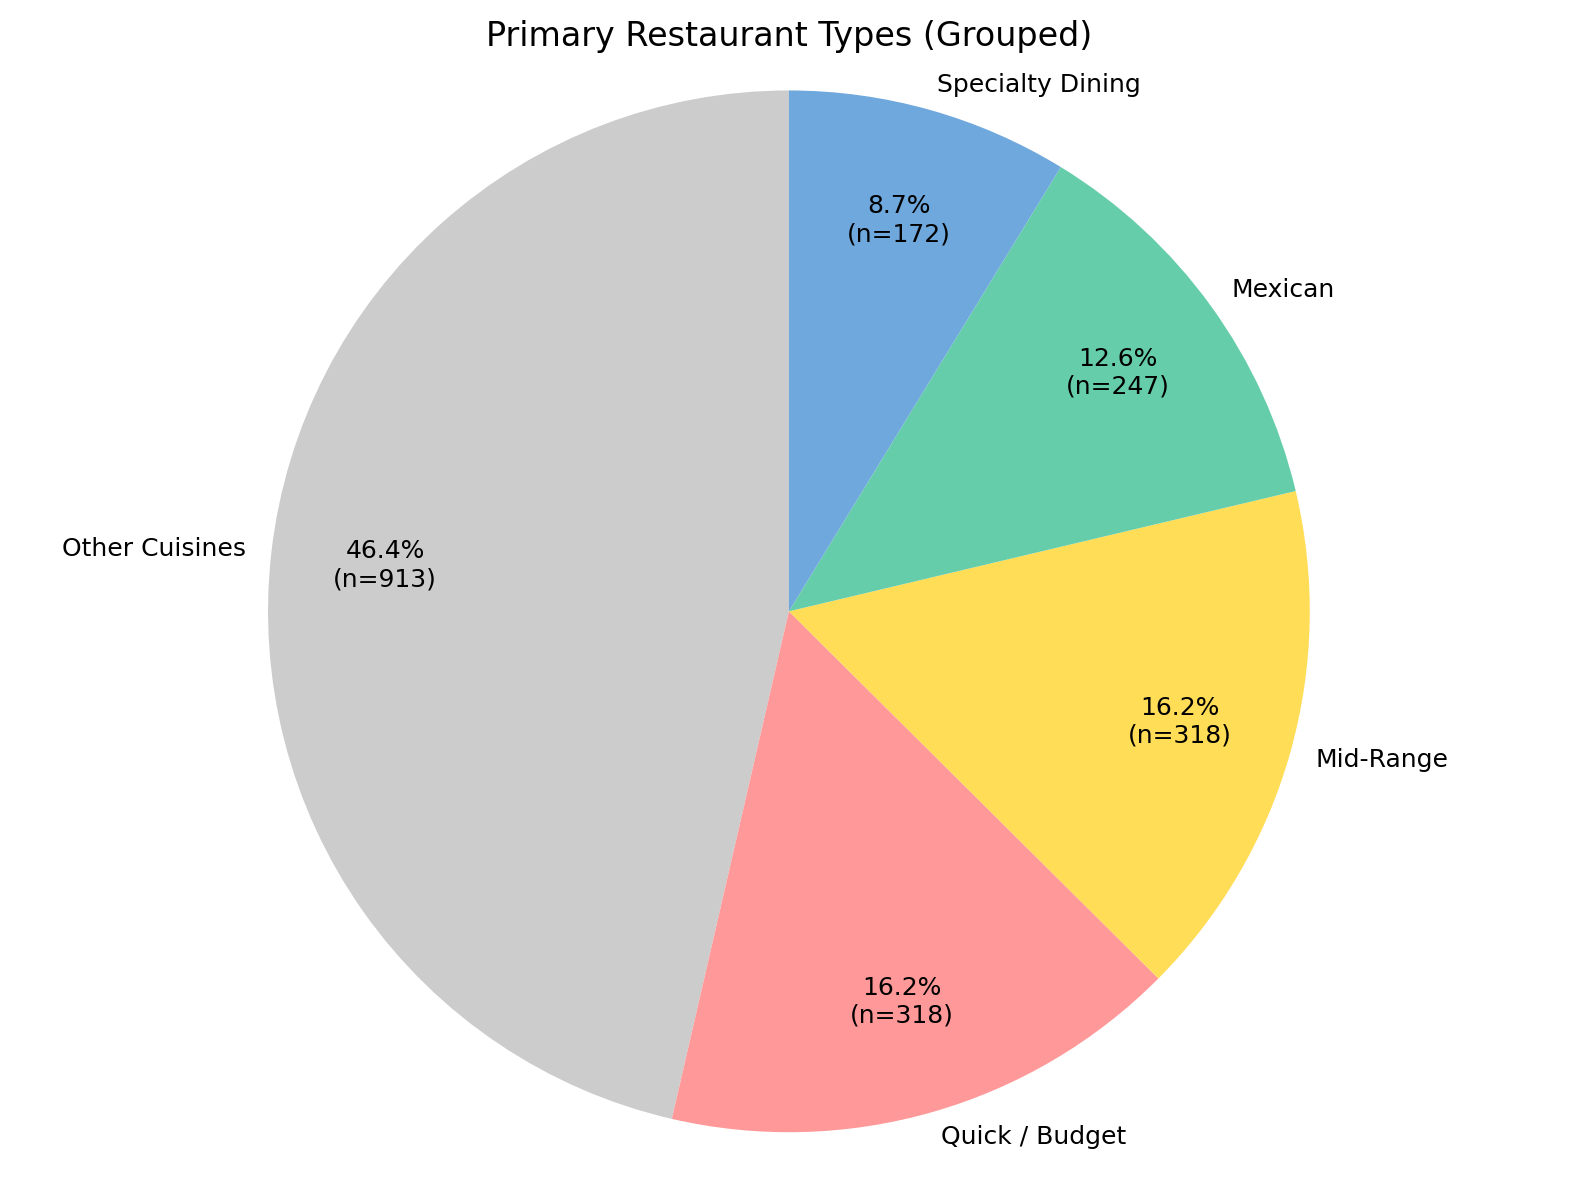

In [27]:
# group restaurant types into broader categories for comparison
def autopct_with_counts(vals):
    total = sum(vals)
    def _fmt(pct):
        n = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={n})"
    return _fmt

def broad_category(t):
    budget = {"Fast Food", "Burgers", "Chicken Wings", "Sandwiches"}
    midrange = {"Pizza", "Chinese", "American"}
    specialty = {"Breakfast & Brunch", "Seafood"}
    if t in budget:
        return "Quick / Budget"
    elif t == "Mexican":
        return "Mexican"
    elif t in midrange:
        return "Mid-Range"
    elif t in specialty:
        return "Specialty Dining"
    else:
        return "Other Cuisines"

plot_df["type_broad"] = plot_df["type_top"].apply(broad_category)

broad_counts = plot_df["type_broad"].value_counts()

broad_colors = {
    "Quick / Budget": "#ff9999",
    "Mexican": "#66cdaa",
    "Mid-Range": "#ffdd57",
    "Specialty Dining": "#6fa8dc",
    "Other Cuisines": "#cccccc",
}

# grouped pie chart
plt.figure(figsize=(8, 6), dpi=200)
plt.pie(broad_counts.values, labels=broad_counts.index,
        colors=[broad_colors[t] for t in broad_counts.index],
        autopct=autopct_with_counts(broad_counts.values),
        pctdistance=0.78, textprops={"fontsize": 9}, labeldistance=1.05,
        startangle=90)
plt.title("Primary Restaurant Types (Grouped)")
plt.axis("equal")
plt.tight_layout()
plt.show()

Quick/Budget and Mexican restaurants together account for nearly 29% of all restaurants, while Mid-Range categories (Pizza, Chinese, American) make up another 16%. Specialty Dining (Breakfast & Brunch, Seafood) represents a smaller 8.7% share. The largest segment remains Other Cuisines (46.4%), reflecting the wide diversity of Chicago's restaurant landscape beyond the most common types.

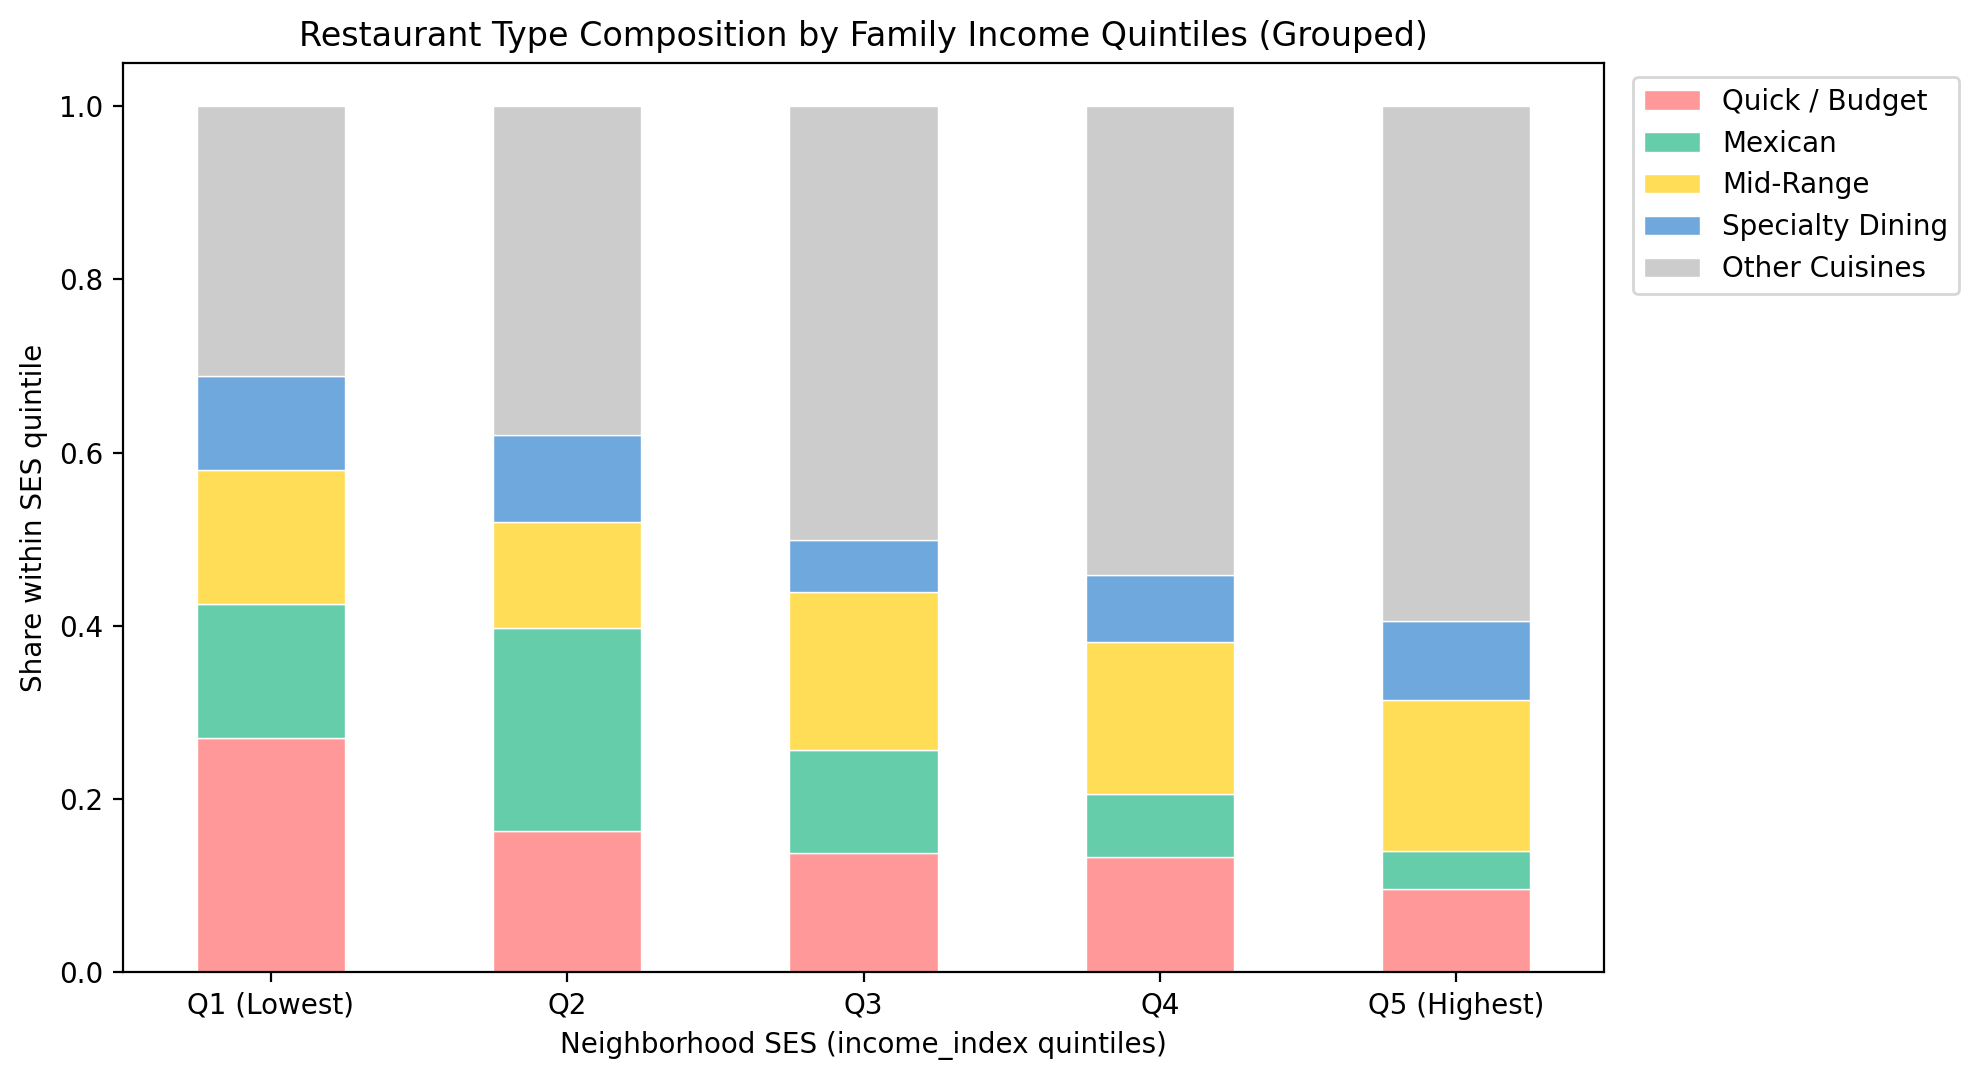

In [37]:
# grouped stacked bar
share_mat_broad = pd.crosstab(plot_df["ses_q"], plot_df["type_broad"], normalize="index")
col_order = ["Quick / Budget", "Mexican", "Mid-Range", "Specialty Dining", "Other Cuisines"] # reorder columns 
share_mat_broad = share_mat_broad.reindex(columns=col_order)

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=200)
share_mat_broad.plot(kind="bar", stacked=True, ax=ax,
                     color=[broad_colors[t] for t in share_mat_broad.columns],
                     edgecolor="white", linewidth=0.5)

ax.set_ylabel("Share within SES quintile")
ax.set_xlabel("Neighborhood SES (income_index quintiles)")
ax.set_title("Restaurant Type Composition by Family Income Quintiles (Grouped)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

Restaurant type composition shifts systematically across income quintiles. Quick/Budget and Mexican restaurants together make up over 40% of restaurants in the lowest-income areas (Q1) but drop to roughly 13% in the highest-income areas (Q5). Meanwhile, Specialty Dining, Mid-Range, and especially Other Cuisines grow in share as neighborhood income increases. This suggests that the SES–restaurant relationship operates less through a concentration of high-end restaurants and more through greater cuisine diversity in wealthier neighborhoods.

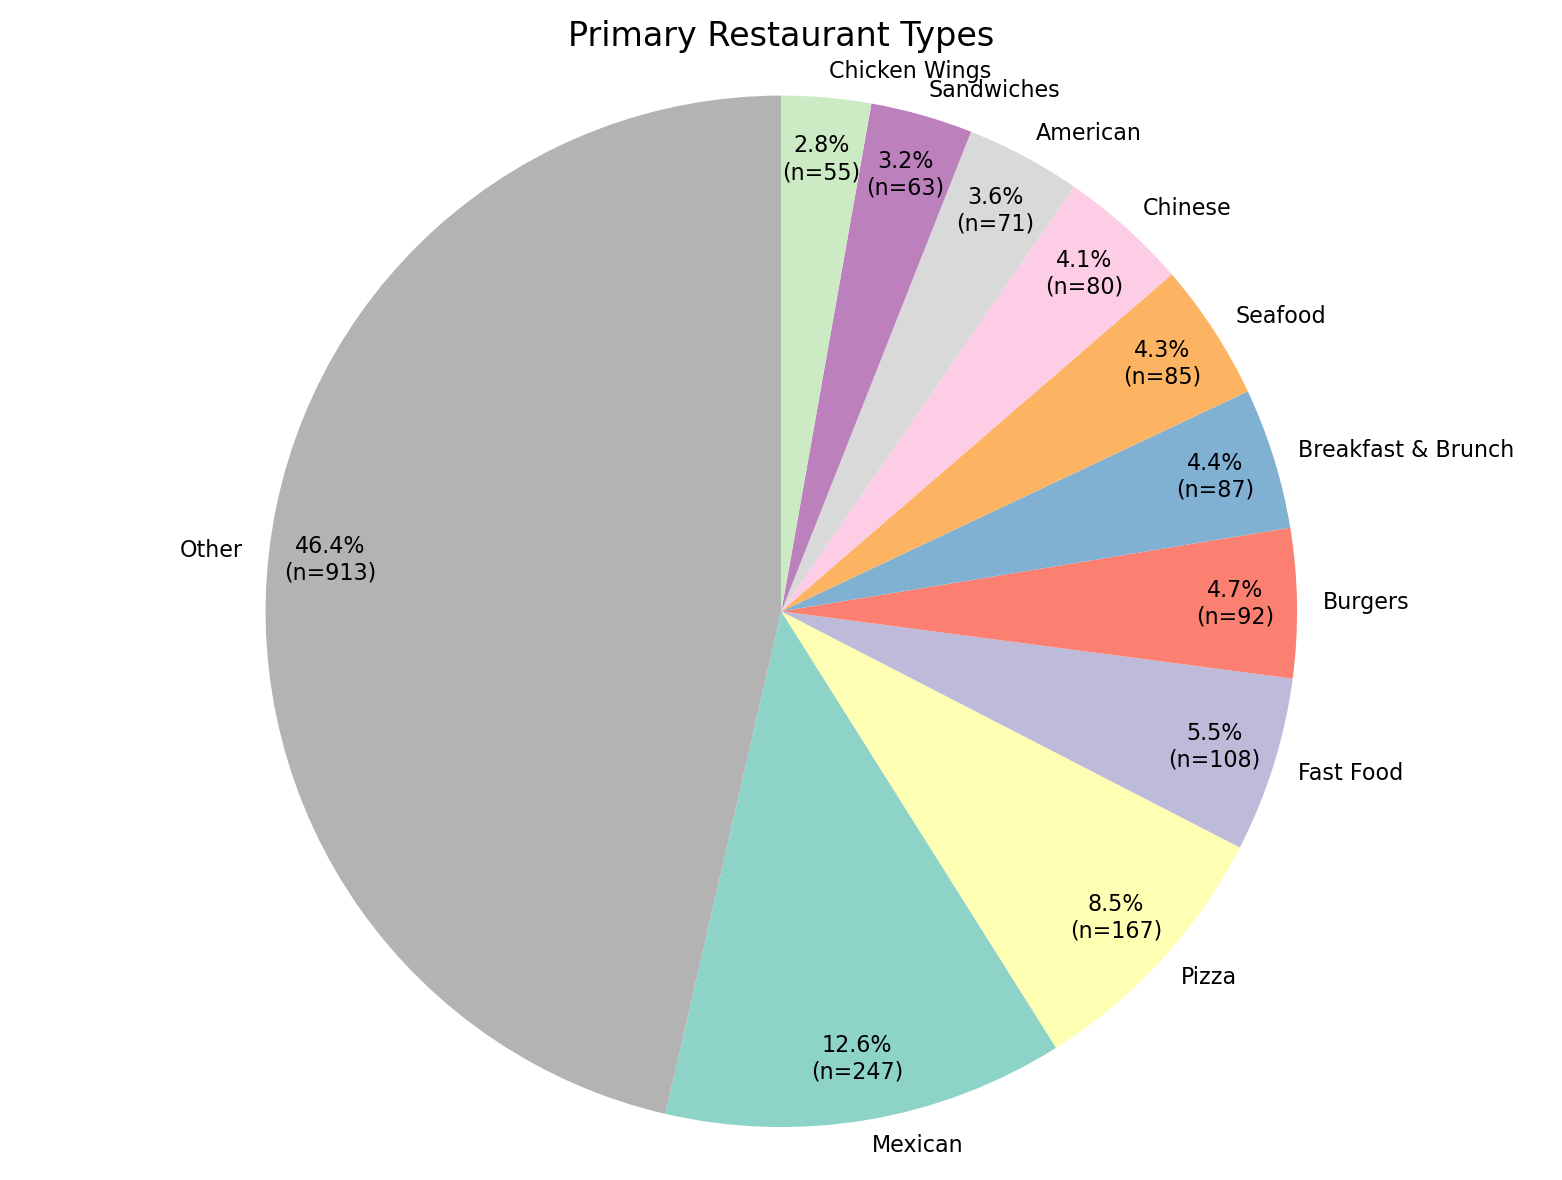

In [28]:
# Primary Restaurant Types pie chart
plt.figure(figsize=(8, 6), dpi =200)  
plt.pie(pie_counts.values,labels=pie_counts.index,colors=[type2color[t] for t in pie_counts.index],autopct=autopct_with_counts(pie_counts.values),
    pctdistance= 0.88, textprops={"fontsize": 8}, labeldistance=1.05,startangle=90)
plt.title(f"Primary Restaurant Types")
plt.axis("equal")
plt.tight_layout()
plt.show()

The overall restaurant landscape is highly concentrated in a few major categories. The “Other” group represents nearly half of all restaurants, followed by Mexican and Pizza as the largest named categories. Mid-sized categories such as Fast Food, Burgers, and Breakfast & Brunch account for moderate shares, while individual specialty types (for example, Seafood, Chinese, American, Sandwiches, and Chicken Wings) comprise smaller proportions. Notably, the “Other” category captures a wide range of cuisines beyond top 10 types, reflecting the diverse set of dining options in Chicago and its broader identity as an immigrant city with a highly varied food culture.

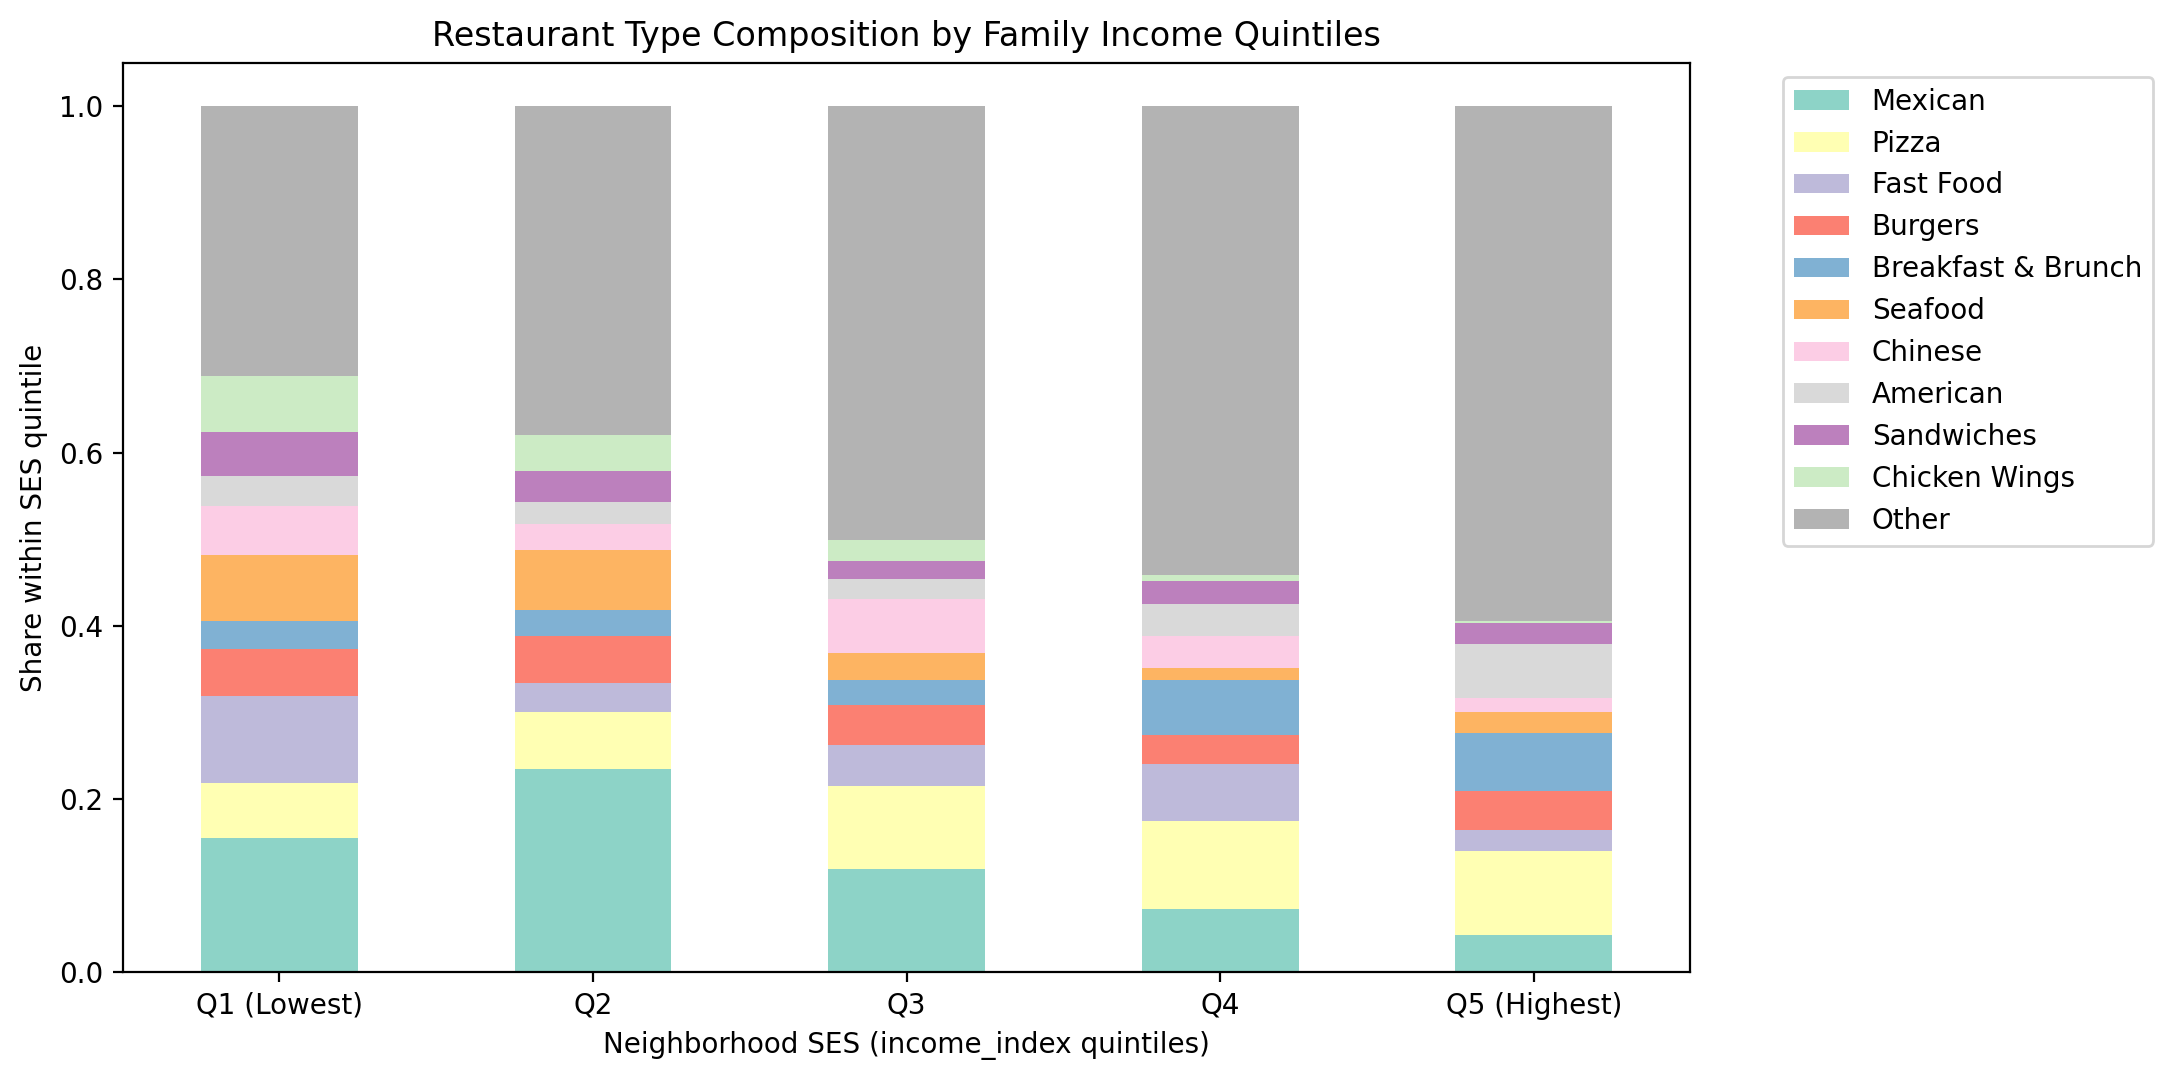

In [29]:
# Restaurant Type Composition by Family Income Quintiles stacked bar 
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=200)
share_mat2.plot(kind="bar", stacked=True, ax=ax, color=[type2color[t] for t in share_mat2.columns], linewidth=0.8)

ax.set_ylabel("Share within SES quintile")
ax.set_xlabel("Neighborhood SES (income_index quintiles)")
ax.set_title("Restaurant Type Composition by Family Income Quintiles")
ax.legend(bbox_to_anchor=(1.05, 1))
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Restaurant type composition shifts noticeably across neighborhood income quintiles. Lower-income areas have higher shares of Mexican and fast-food establishments, whereas higher-income neighborhoods show relatively larger shares of pizza, breakfast and brunch, and certain sit-down categories. The “Other” category remains substantial across all quintiles but increases somewhat in higher-income areas, suggesting greater cuisine diversity at the upper end of the SES distribution. Overall, the figure indicates that cuisine mix varies with neighborhood income, reinforcing the broader pattern that restaurant characteristics are systematically associated with local socioeconomic conditions.

### Regression

Build 3-model regression set (OLS, cluster SE) with same sample

    Model 1 Baseline:  price ~ income_z + services

    Model 2 Baseline + quality: price ~ income_z + services + res_rating + log_reviews

    Model 3 Baseline + quality + type + hours: price ~ income_z + services + res_rating + log_reviews + primary_type dummies + opening-hours controls

The outcome (DV) is res_price_level (1–4); SE is clustered at community-area level (AREA_NUMBE)

In [30]:
y_col = "res_price_level"

service_cols = ["res_pickup", "res_takeout", "res_delivery", "res_dine_in", "res_reservable"]

# build modeling dataset 
model_df = gp_yelp_join.merge(comm_ses[["AREA_NUMBE", "income_index"]], on="AREA_NUMBE", how="left").copy()
need_cols = [y_col, "income_index", "AREA_NUMBE"] + service_cols + ["res_rating", "res_review_count", "res_primary_type"]
model_df = model_df.dropna(subset=need_cols).copy()

# numeric casting
model_df[y_col] = pd.to_numeric(model_df[y_col], errors="coerce")
model_df["income_index"] = pd.to_numeric(model_df["income_index"], errors="coerce")
model_df["AREA_NUMBE"] = pd.to_numeric(model_df["AREA_NUMBE"], errors="coerce")
model_df["res_rating"] = pd.to_numeric(model_df["res_rating"], errors="coerce")
model_df["res_review_count"] = pd.to_numeric(model_df["res_review_count"], errors="coerce")
for c in service_cols: model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df = model_df.dropna(subset=[y_col, "income_index", "AREA_NUMBE", "res_rating", "res_review_count"] + service_cols).copy()
model_df[y_col] = model_df[y_col].astype(int)

# standardize income
model_df["income_z"] = (model_df["income_index"] - model_df["income_index"].mean()) / model_df["income_index"].std(ddof=0)

# log(review_count + 1); use log transformation to reduce right-skewness in review counts, and add +1 to avoid taking log(0) for restaurants with zero reviews
model_df["log_reviews"] = np.log(model_df["res_review_count"] + 1)

# change primary restaruant type into dummies (Top 10 + Other)
TOP_K_TYPES = 10  
top_types = model_df["res_primary_type"].value_counts().head(TOP_K_TYPES).index
model_df["res_primary_type_top"] = model_df["res_primary_type"].where(model_df["res_primary_type"].isin(top_types), "OtherType")

type_dummies = pd.get_dummies(model_df["res_primary_type_top"].fillna("Unknown"), prefix="type", drop_first=True).astype(int)
model_df = pd.concat([model_df, type_dummies], axis=1); type_cols = list(type_dummies.columns)

# helper function to fit model + print result
def fit_cluster_ols(df, x_cols, title):
    df_use = df.dropna(subset=x_cols + [y_col, "AREA_NUMBE"]).copy()
    y = pd.to_numeric(df_use[y_col], errors="coerce"); X = df_use[x_cols].apply(pd.to_numeric, errors="coerce")
    X = sm.add_constant(X, has_constant="add")
    ok = y.notna() & X.notna().all(axis=1)
    df_use = df_use.loc[ok].copy()
    y = y.loc[ok]; X = X.loc[ok]
    res = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": df_use["AREA_NUMBE"]})

    print("\n" + "-" * 60)
    print(title)
    print(f"N = {len(df_use):,} | # areas = {df_use['AREA_NUMBE'].nunique():,} | R^2 = {res.rsquared:.3f}")
    print("-" * 60)
    print(res.summary())
    return res

In [31]:
# Model 1 Baseline
x1 = ["income_z"] + service_cols
res_1 = fit_cluster_ols(model_df,x1, "Model 1 (Baseline): price ~ income_z + services")


------------------------------------------------------------
Model 1 (Baseline): price ~ income_z + services
N = 1,803 | # areas = 73 | R^2 = 0.296
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:        res_price_level   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     57.72
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           1.51e-25
Time:                        11:55:27   Log-Likelihood:                -1320.9
No. Observations:                1803   AIC:                             2656.
Df Residuals:                    1796   BIC:                             2694.
Df Model:                           6                                         
Covariance Type:              cluster                                         


Model 1 (Baseline: income + services) 

Using 1,803 restaurants, the baseline model explains a moderate share of variation in restaurant price levels (R^2 = 0.296)

Neighborhood income is strongly and positively associated with price: a one-standard-deviation increase in income_z corresponds to a 0.168 increase in res_price_level (b = 0.168, p < 0.001). This reflects a systematic association between neighborhood SES and restaurant price levels.

Among service attributes, whether a restaurant is reservable is a large and highly significant positive correlate of higher price levels (b = 0.432, p < 0.001), while takeout availability is significantly associated with lower prices (b = −0.721, p = 0.001). The relatively large coefficient on takeout reflects that it captures broader differences in restaurants in this baseline model with a limited set of controls. Other service indicators (pickup, delivery, and dine-in) are not statistically distinguishable from zero in this specification.

Overall, Model 1 establishes that both neighborhood SES and certain service formats (especially reservations and takeout) are systematically related to price levels.

In [32]:
# Model 2 Baseline + rating + log_reviews
x2 = ["income_z"] + service_cols + ["res_rating", "log_reviews"]
res_2 = fit_cluster_ols(model_df,x2,"Model 2 (+rating + log_reviews): price ~ income_z + services + rating + log_reviews")


------------------------------------------------------------
Model 2 (+rating + log_reviews): price ~ income_z + services + rating + log_reviews
N = 1,803 | # areas = 73 | R^2 = 0.323
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:        res_price_level   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     51.49
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           9.34e-27
Time:                        11:55:27   Log-Likelihood:                -1285.5
No. Observations:                1803   AIC:                             2589.
Df Residuals:                    1794   BIC:                             2639.
Df Model:                           8                                         
Covariance Type:              cluster      

Model 2 (Baseline + rating + log_reviews)

Adding quality signals (res_rating and log_reviews) improves model fit (R^2 rises from 0.296 to 0.323), indicating that ratings and review volume explain additional variation beyond SES and service structure. The income coefficient decreases from 0.168 to 0.123 (b = 0.123, p < 0.001) but remains strongly significant. This indicates that quality signals partially account for the SES–price relationship, but neighborhood income remains independently associated with price levels.

Both quality indicators are positive and statistically significant: res_rating: b = 0.202, p < 0.001; log_reviews: b = 0.056, p < 0.001.

Besides, higher-rated and more frequently reviewed restaurants tend to be more expensive, even after controlling for neighborhood SES and services.

Importantly, the reservable (b = 0.386, p < 0.001) and takeout (b = −0.712, p = 0.001) effects remain similar in magnitude and significance, reinforcing their robustness. Thus, Model 2 builds on the baseline by showing that quality signals partially mediate—but do not eliminate—the SES–price relationship.

In [33]:
# Model 3 Baseline + rating + log_reviews + type + hours
hours_cols = ["gp_total_open_minutes_week", "gp_open_late_minutes"]

# keep Model 1–2 sample intact; only restrict sample for Model 3 if hours are missing
model_df3 = model_df.dropna(subset=hours_cols).copy()

for c in hours_cols:
    model_df3[c] = pd.to_numeric(model_df3[c], errors="coerce")

model_df3 = model_df3.dropna(subset=hours_cols).copy()

model_df3["open_total_z"] = (model_df3["gp_total_open_minutes_week"] - model_df3["gp_total_open_minutes_week"].mean()) / model_df3["gp_total_open_minutes_week"].std(ddof=0)

model_df3["open_late_z"] = (model_df3["gp_open_late_minutes"] - model_df3["gp_open_late_minutes"].mean()) / model_df3["gp_open_late_minutes"].std(ddof=0)

x3 = ["income_z"] + service_cols + ["res_rating", "log_reviews"] + type_cols + ["open_total_z", "open_late_z"]
res_3 = fit_cluster_ols(model_df3,x3, "Model 3 (+type + hours): price ~ income_z + services + rating + log_reviews + primary_type + opening hours")

print("\nModel 3 sample (requires hours non-missing):")
print("N =", len(model_df3), "| # areas =", model_df3["AREA_NUMBE"].nunique())


------------------------------------------------------------
Model 3 (+type + hours): price ~ income_z + services + rating + log_reviews + primary_type + opening hours
N = 1,800 | # areas = 73 | R^2 = 0.391
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:        res_price_level   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     68.37
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           8.37e-39
Time:                        11:55:27   Log-Likelihood:                -1189.2
No. Observations:                1800   AIC:                             2420.
Df Residuals:                    1779   BIC:                             2536.
Df Model:                          20                                         
Covariance Type:    

Model 3 (Model 3 Baseline + rating + log_reviews + type + hours)

Model 3 adds primary restaurant-type dummies and standardized opening-hours measures. The sample size is N = 1,800 (73 areas), and model fit improves substantially (R^2 = 0.391), indicating that category composition explains a noticeable share of price variation.

The SES gradient remains positive and statistically significant, though further attenuated slightly. This progressive decline of income_z (from 0.168 to 0.123 to 0.105) suggests that part of the neighborhood income gradient operates through both quality signals and restaurant-type composition, yet a meaningful independent association remains.

Service effects continue to show consistent patterns: res_reservable: b = 0.315, p < 0.001; res_takeout: b = −0.637, p = 0.002.

Quality signals remain significant but somewhat smaller:res_rating: b = 0.098, p = 0.001; log_reviews: b = 0.064, p < 0.001.

Several restaurant types differ significantly from the omitted reference category. For example, Fast Food, Burgers, Chinese, Mexican, and Sandwiches are associated with lower price levels, while Seafood is positively associated with higher prices. These patterns confirm that cuisine composition accounts for a substantial portion of observed price differences.

Opening intensity contributes relatively little beyond these controls: open_total_z: b = −0.034, p = 0.025; open_late_z: b = 0.0002, p = 0.991.

In [57]:
# regression comparison table
def format_coef(params, pvalues, var):
    if var not in params.index:
        return ""
    b = params[var]
    p = pvalues[var]
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    return f"{b:.3f}{stars}"

def format_se(bse, var):
    if var not in bse.index:
        return ""
    return f"({bse[var]:.3f})"

# define row order
row_vars = [
    ("income_z", "Income (z-score)"),
    ("res_takeout", "Takeout"),
    ("res_delivery", "Delivery"),
    ("res_dine_in", "Dine-in"),
    ("res_reservable", "Reservable"),
    ("res_pickup", "Pickup"),
    ("res_rating", "Rating"),
    ("log_reviews", "Log reviews"),
    ("open_total_z", "Open hours (z)"),
    ("open_late_z", "Late hours (z)"),
]
models = [("Model 1", res_1),("Model 2", res_2),("Model 3", res_3),]

rows = []
for var, label in row_vars:
    coef_row = [label]
    se_row = [""]
    for name, res in models:
        coef_row.append(format_coef(res.params, res.pvalues, var))
        se_row.append(format_se(res.bse, var))
    rows.append(coef_row)
    rows.append(se_row)

# add model stats
rows.append([""] + ["" for _ in models])  # blank separator
rows.append(["Type dummies"] + ["No", "No", "Yes"])
rows.append(["N"] + [str(int(res.nobs)) for _, res in models])
rows.append(["R²"] + [f"{res.rsquared:.3f}" for _, res in models])

col_names = [""] + [name for name, _ in models]
table_df = pd.DataFrame(rows, columns=col_names)

output = table_df.to_string(index=False)
for line in output.split("\n"):
    print(line)

table_df.to_csv("regression_table.csv", index=False)

                  Model 1   Model 2  Model 3
Income (z-score) 0.168***  0.123*** 0.105***
                  (0.019)   (0.019)  (0.017)
         Takeout -0.721** -0.712*** -0.637**
                  (0.225)   (0.212)  (0.201)
        Delivery   -0.025     0.006   -0.000
                  (0.055)   (0.058)  (0.051)
         Dine-in   -0.028    -0.067    0.042
                  (0.043)   (0.043)  (0.042)
      Reservable 0.432***  0.386*** 0.315***
                  (0.036)   (0.031)  (0.029)
          Pickup   -0.000    -0.009   -0.009
                  (0.030)   (0.031)  (0.032)
          Rating           0.202*** 0.098***
                            (0.033)  (0.030)
     Log reviews           0.056*** 0.064***
                            (0.014)  (0.014)
  Open hours (z)                     -0.034*
                                     (0.015)
  Late hours (z)                       0.000
                                     (0.017)
                                            
    Type d

Across the three models, fit increases as we add quality signals and restaurant composition (R^2 rises from 0.296 to 0.323 to 0.391). It is noticeable that neighborhood income is positively correlated with restaurant price levels in every specification (income_z declines from 0.168 to 0.123 to 0.105, all p < 0.001). This aligns with our expectation that restaurants respond to local consumer demand and consumption habits—higher-income neighborhoods tend to support and attract higher-priced dining options. In addition, platform signals and operational features help explain further variation in price: higher ratings and greater review volume are associated with higher price levels, and “reservable” status is a strong positive correlate of higher prices, whereas takeout availability is associated with lower prices.

### Discussion

Overall, the analysis does answer both research questions using  evidence from spatial visualizations and a sequence of regression models with clustered standard errors.

RQ1: Price–SES (Income-Price Level)

Answered: Yes. Restaurant prices are systematically higher in higher-SES neighborhoods.
 - Visualization evidence: 
 	 - Maps and SES-quintile plots show that price tiers 3–4 cluster in central /lakefront / higher-income areas, while lower-income neighborhoods have a larger share of tier-1 options. This indicates a clear spatial and socioeconomic gradient in price.
 - Regression evidence: 
 	 - Across Model 1–3, income remains a positive and statistically significant predictor of restaurant price level. The income coefficient attenuates as controls are added (from 0.168 to 0.123 to 0.105), implying that some of the SES–price association operates through observable “quality” signals and restaurant composition, but a meaningful independent SES association remains.

RQ2: Characteristics–SES (Do restaurant features vary by neighborhood SES?)

Answered: Yes. Multiple restaurant characteristics vary systematically across neighborhoods, and the patterns align with SES stratification.
 - Visualization evidence:
	 - Formal dining features (especially reservable and dine-in) become more common in higher-income quintiles.
	 - The grouped type analysis further shows that Quick/Budget and Mexican restaurants together account for over 40% of restaurants in the lowest-income areas (Q1) but drop to below 15% in the highest-income areas (Q5), while Mid-Range, Specialty Dining, and especially Other Cuisines increase in share, indicating greater cuisine diversity in higher-income areas.
 - Regression evidence:
	 - Reservable status is a strong positive correlate of higher prices (consistent across models).
	 - Takeout availability is negatively associated with price (consistent with lower-tier).
	 - Ratings and review volume are positively associated with price.
	 - Restaurant-type dummies explain a substantial portion of price variation (Model 3 fit increases notably), reinforcing that neighborhood composition differs in economically meaningful ways.
	- Total and late opening-hours contribute little beyond other controls.


### Summary and Conclusion

Research Questions
 - RQ1: How are restaurant prices (price level) associated with neighborhood socioeconomic status (SES), measured by median household income, across Chicago?
 - RQ2: Do restaurant characteristics (type, service options, hours, ratings, and review count) vary systematically across neighborhoods with different socioeconomic status?

Key Findings
 - Clear SES–price gradient: Visualizations and regression results show that higher-income community areas tend to have higher average restaurant price levels.
 - Relationship remains after controls: Regression models demonstrate that neighborhood income remains a significant positive predictor of restaurant price even after controlling for ratings, review volume, service features, and restaurant type.
 - Restaurant features differ across neighborhoods: Higher-income areas have a greater concentration of formal dining features such as reservable and dine-in restaurants.
 - Operational features relate to price: Restaurants with reservations and higher ratings/review volume are associated with higher price levels, while takeout availability is associated with lower prices.
 - Cuisine composition contributes to price variation: Restaurant type improves model fit; fast food–type categories are linked to lower prices, while seafood is associated with higher prices.

Limitations
  - SES is primarily measured using median household income, which may not capture the full socioeconomic background of neighborhoods.
  - Price levels, ratings, and service attributes are derived from platform data and may contain missing values or measurement noise.
  - The results identify correlations rather than causal relationships between neighborhood SES and restaurant characteristics.

Possible Improvements
 -  Incorporate additional socioeconomic variables such as education, unemployment rate, or housing costs.
 -  Include more detailed measures of restaurant quality, amenities, and consumer demand patterns.
 -  Compare Chicago with other metropolitan areas to examine whether similar SES–restaurant patterns hold elsewhere.

